# 02 — Analyze Results

**Sections:**
- §0: Setup & Data Loading
- §1: Health Check & Issue Detection
- §2: DV 1 — Output Quality
- §3: DV 2 — Efficiency
- §4: DV 4 — Worker Satisfaction
- §5: Cross-DV Correlations
- §6: Statistical Tests

---
## §0 — Setup & Data Loading

In [57]:
import json
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore', category=FutureWarning)

RESULTS_DIR = Path('../results')

STYLE_ORDER = [
    'baseline', 'coercive', 'authoritative', 'affiliative',
    'democratic', 'pacesetting', 'coaching'
]

STYLE_COLORS = {
    'coercive':     '#E74C3C',
    'affiliative':  '#27AE60',
    'democratic':   '#2980B9',
    'coaching':     '#F1C40F',
    'pacesetting':  '#8E44AD',
    'authoritative':'#E67E22',
    'baseline':     '#95A5A6',
}

TASK_TYPES = ['short', 'long']
N_REPS = 5

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 120,
})
sns.set_style('whitegrid')

print('Setup complete.')

Setup complete.


### §0.1 — Load experiment data

In [58]:
def parse_run_folder(name: str) -> dict | None:
    """Extract style, task, run_id from folder name like 'coercive_short_run01'."""
    m = re.match(r'^(\w+)_(short|long)_run(\d+)$', name)
    if not m:
        return None
    return {'style': m.group(1), 'task': m.group(2), 'run_id': int(m.group(3))}


def load_json(path: Path) -> dict | None:
    """Safely load a JSON file, return None if missing or invalid."""
    if not path.exists():
        return None
    try:
        return json.loads(path.read_text())
    except (json.JSONDecodeError, UnicodeDecodeError):
        return None


def load_jsonl(path: Path) -> list[dict]:
    """Safely load a JSONL file, return list of dicts."""
    if not path.exists():
        return []
    lines = []
    for line in path.read_text().strip().split('\n'):
        if line.strip():
            try:
                lines.append(json.loads(line))
            except json.JSONDecodeError:
                pass
    return lines


# Discover all experiment run folders
rows = []
missing_files_log = []

for folder in sorted(RESULTS_DIR.iterdir()):
    if not folder.is_dir():
        continue
    parsed = parse_run_folder(folder.name)
    if parsed is None:
        continue  # skip test runs, .DS_Store, etc.

    row = {**parsed, 'folder': folder.name}

    # metadata.json
    meta = load_json(folder / 'metadata.json')
    if meta:
        row['total_tokens']       = meta.get('total_tokens')
        row['total_input_tokens'] = meta.get('total_input_tokens')
        row['total_output_tokens']= meta.get('total_output_tokens')
        row['total_messages']     = meta.get('total_messages')
        row['total_api_calls']    = meta.get('total_api_calls')
        row['total_code_execs']   = meta.get('total_code_executions')
        row['duration_seconds']   = meta.get('duration_seconds')
        row['revision_rounds']    = meta.get('revision_rounds')
        row['max_revision_rounds']= meta.get('max_revision_rounds', 2)
        # Per-agent token usage
        agent_usage = meta.get('token_usage_by_agent', {})
        for agent in ['Boss', 'Coder', 'Writer', 'Reviewer']:
            au = agent_usage.get(agent, {})
            row[f'{agent.lower()}_tokens'] = au.get('total_tokens', 0)
            row[f'{agent.lower()}_calls']  = au.get('call_count', 0)
    else:
        missing_files_log.append((folder.name, 'metadata.json'))

    # evaluation.json
    ev = load_json(folder / 'evaluation.json')
    if ev:
        row['eval_valid']       = ev.get('valid', False)
        row['quality_mean']     = ev.get('quality_mean')
        row['overall_quality']  = ev.get('overall_quality')
        row['trap_catch_rate']  = ev.get('trap_catch_rate')
        row['eval_summary']     = ev.get('summary', '')
        # Individual scores
        scores = ev.get('scores', {})
        for dim in ['accuracy', 'completeness', 'cohesion', 'quality']:
            row[f'score_{dim}'] = scores.get(dim, {}).get('score')
        # Trap details
        traps = ev.get('traps', {})
        for trap_name, trap_data in traps.items():
            row[f'trap_{trap_name}'] = trap_data.get('status', 'unknown')
    else:
        missing_files_log.append((folder.name, 'evaluation.json'))

    # survey_results.json
    survey = load_json(folder / 'survey_results.json')
    if survey:
        row['survey_team_mean'] = survey.get('team_mean')
        workers = survey.get('workers', {})
        composites = []
        for agent in ['Coder', 'Writer', 'Reviewer']:
            w = workers.get(agent, {})
            comp = w.get('composite_score')
            row[f'survey_{agent.lower()}'] = comp
            row[f'survey_{agent.lower()}_valid'] = w.get('valid', False)
            if comp is not None:
                composites.append(comp)
            # Per-question adjusted scores
            adj = w.get('adjusted_scores', {})
            for q in ['q1', 'q2', 'q3', 'q4', 'q5', 'q6']:
                row[f'survey_{agent.lower()}_{q}'] = adj.get(q)
        # Flag: all composites identical?
        if len(composites) == 3:
            row['survey_identical'] = (composites[0] == composites[1] == composites[2])
        else:
            row['survey_identical'] = None
    else:
        missing_files_log.append((folder.name, 'survey_results.json'))

    # sentiment.json (aggregates only)
    sent = load_json(folder / 'sentiment.json')
    if sent:
        row['sentiment_valid'] = sent.get('valid', False)
        agg = sent.get('aggregates', {}).get('run', {})
        row['sentiment_mean']   = agg.get('mean_compound')
        row['sentiment_median'] = agg.get('median_compound')
        row['sentiment_std']    = agg.get('std_compound')
        # Boss vs workers
        bvw = sent.get('aggregates', {}).get('boss_vs_workers', {})
        row['sentiment_boss']   = bvw.get('boss_mean')
        row['sentiment_worker'] = bvw.get('worker_mean')
        row['sentiment_gap']    = bvw.get('gap')
    else:
        missing_files_log.append((folder.name, 'sentiment.json'))

    rows.append(row)

# Build master DataFrame
df = pd.DataFrame(rows)
df['style'] = pd.Categorical(df['style'], categories=STYLE_ORDER, ordered=True)
df = df.sort_values(['style', 'task', 'run_id']).reset_index(drop=True)

print(f'Loaded {len(df)} experiment runs from {RESULTS_DIR}')
print(f'Styles:  {sorted(df["style"].unique())}')
print(f'Tasks:   {sorted(df["task"].unique())}')
print(f'Run IDs: {sorted(df["run_id"].unique())}')
print(f'\nMissing files: {len(missing_files_log)}')
if missing_files_log:
    for folder, fname in missing_files_log[:10]:
        print(f'  ⚠ {folder}: missing {fname}')
    if len(missing_files_log) > 10:
        print(f'  ... and {len(missing_files_log) - 10} more')

df.head(3)

Loaded 70 experiment runs from ../results
Styles:  ['affiliative', 'authoritative', 'baseline', 'coaching', 'coercive', 'democratic', 'pacesetting']
Tasks:   ['long', 'short']
Run IDs: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Missing files: 0


,style,task,run_id,folder,total_tokens,total_input_tokens,total_output_tokens,total_messages,total_api_calls,total_code_execs,...,survey_identical,sentiment_valid,sentiment_mean,sentiment_median,sentiment_std,sentiment_boss,sentiment_worker,sentiment_gap,trap_single_observation_cities,trap_country_name_duplicates
0,baseline,long,1,baseline_long_run01,700811,633471,67340,31,31,6,...,True,True,0.2444,0.6826,0.8218,0.5888,-0.0140,0.6028,NaN,NaN
1,baseline,long,2,baseline_long_run02,347174,317340,29834,25,21,2,...,False,True,0.8149,0.9660,0.2647,0.8403,0.7926,0.0477,NaN,NaN
2,baseline,long,3,baseline_long_run03,319993,285656,34337,27,23,2,...,False,True,0.4536,0.9442,0.7973,0.9584,0.1003,0.8581,NaN,NaN


In [59]:
# save df in the folder from the notebooks as excel file 
# df.to_excel('/Users/hellligkeit/Documents/FS/Masterthesis/MAS/notebooks/dataframe.xlsx')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 70 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   style                           70 non-null     category
 1   task                            70 non-null     str     
 2   run_id                          70 non-null     int64   
 3   folder                          70 non-null     str     
 4   total_tokens                    70 non-null     int64   
 5   total_input_tokens              70 non-null     int64   
 6   total_output_tokens             70 non-null     int64   
 7   total_messages                  70 non-null     int64   
 8   total_api_calls                 70 non-null     int64   
 9   total_code_execs                70 non-null     int64   
 10  duration_seconds                70 non-null     float64 
 11  revision_rounds                 70 non-null     int64   
 12  max_revision_rounds             70 

---
## §1 — Health Check & Issue Detection

### §1a — Completeness Check

In [60]:
# Completeness: 7 styles × 2 tasks × 5 reps = 70 runs expected
completeness = df.groupby(['style', 'task']).size().unstack(fill_value=0)
completeness.columns.name = None

# Highlight cells that don't have exactly N_REPS
def highlight_incomplete(val):
    if val < N_REPS:
        return 'background-color: #FADBD8; font-weight: bold'
    return 'background-color: #D5F5E3'

print(f'Expected: {len(STYLE_ORDER)} styles × {len(TASK_TYPES)} tasks × {N_REPS} reps = '
      f'{len(STYLE_ORDER) * len(TASK_TYPES) * N_REPS} runs')
print(f'Found:    {len(df)} runs\n')

completeness.style.map(highlight_incomplete)

Expected: 7 styles × 2 tasks × 5 reps = 70 runs
Found:    70 runs



,long,short
style,,
baseline,5,5
coercive,5,5
authoritative,5,5
affiliative,5,5
democratic,5,5
pacesetting,5,5
coaching,5,5


### §1b — Validity Flags

In [61]:
validity_cols = {
    'eval_valid':      'Evaluation',
    'sentiment_valid':  'Sentiment',
    'survey_coder_valid':   'Survey (Coder)',
    'survey_writer_valid':  'Survey (Writer)',
    'survey_reviewer_valid':'Survey (Reviewer)',
}

print('Validity summary (True = valid):\n')
for col, label in validity_cols.items():
    if col in df.columns:
        n_valid = df[col].sum()
        n_total = df[col].notna().sum()
        n_missing = df[col].isna().sum()
        status = '✅' if n_valid == len(df) else '⚠️'
        print(f'  {status} {label}: {n_valid}/{n_total} valid'
              f'{f", {n_missing} missing" if n_missing > 0 else ""}')
    else:
        print(f'  ❌ {label}: column not found')

# Show any invalid runs
invalid_runs = []
for col, label in validity_cols.items():
    if col in df.columns:
        bad = df[df[col] == False]
        for _, r in bad.iterrows():
            invalid_runs.append({'folder': r['folder'], 'issue': f'{label} invalid'})

if invalid_runs:
    print(f'\n⚠️ {len(invalid_runs)} invalid entries:')
    for ir in invalid_runs[:15]:
        print(f"  {ir['folder']}: {ir['issue']}")
else:
    print('\n✅ All validity flags pass.')

Validity summary (True = valid):

  ✅ Evaluation: 70/70 valid
  ✅ Sentiment: 70/70 valid
  ✅ Survey (Coder): 70/70 valid
  ✅ Survey (Writer): 70/70 valid
  ✅ Survey (Reviewer): 70/70 valid

✅ All validity flags pass.


### §1c — Truncation Diagnostic

In [62]:
TRUNC_PATTERNS = re.compile(
    r'truncat|cut off|cut-off|incomplete|abruptly|mid-sentence|cuts off'
    r'|unfinished|stops short|breaks off',
    re.IGNORECASE
)

def check_truncation(folder_path: Path) -> bool:
    """Check if evaluation.json mentions truncation-related issues."""
    ev = load_json(folder_path / 'evaluation.json')
    if not ev:
        return False
    # Check summary + raw_response + all justification texts
    texts = [ev.get('summary', ''), ev.get('raw_response', '')]
    for dim_data in ev.get('scores', {}).values():
        if isinstance(dim_data, dict):
            texts.append(dim_data.get('justification', ''))
    combined = ' '.join(texts)
    return bool(TRUNC_PATTERNS.search(combined))


df['truncation_flagged'] = [
    check_truncation(RESULTS_DIR / folder) for folder in df['folder']
]

# Summary table: style × task → truncation rate
trunc_table = df.groupby(['style', 'task'])['truncation_flagged'].agg(
    ['sum', 'count']
)
trunc_table['rate'] = (trunc_table['sum'] / trunc_table['count'] * 100).round(0).astype(int)
trunc_table['display'] = trunc_table.apply(
    lambda r: f"{int(r['sum'])}/{int(r['count'])} ({int(r['rate'])}%)", axis=1
)
trunc_pivot = trunc_table['display'].unstack(fill_value='0/0 (0%)')

# Overall
n_trunc = df['truncation_flagged'].sum()
pct = n_trunc / len(df) * 100
print(f'Truncation detected in: {n_trunc}/{len(df)} runs ({pct:.0f}%)\n')

# By task
for task in TASK_TYPES:
    subset = df[df['task'] == task]
    n = subset['truncation_flagged'].sum()
    print(f'  {task}: {n}/{len(subset)} ({n/len(subset)*100:.0f}%)')

print('\nTruncation by style × task:\n')
trunc_pivot

Truncation detected in: 49/70 runs (70%)

  short: 18/35 (51%)
  long: 31/35 (89%)

Truncation by style × task:



task,long,short
style,,
baseline,3/5 (60%),4/5 (80%)
coercive,5/5 (100%),3/5 (60%)
authoritative,5/5 (100%),2/5 (40%)
affiliative,4/5 (80%),2/5 (40%)
democratic,5/5 (100%),4/5 (80%)
pacesetting,4/5 (80%),1/5 (20%)
coaching,5/5 (100%),2/5 (40%)


### §1d — Column Name / KeyError Diagnostic

In [63]:
KEYERROR_PATTERN = re.compile(r"KeyError:\s*[\"'](.+?)[\"']", re.IGNORECASE)

code_exec_rows = []

for _, run in df.iterrows():
    folder = RESULTS_DIR / run['folder']
    executions = load_jsonl(folder / 'code_executions.jsonl')

    total = len(executions)
    failed = 0
    keyerror_count = 0
    hallucinated_cols = []

    for ex in executions:
        success = ex.get('success', True)
        stderr = ex.get('stderr', '') or ''
        stdout = ex.get('stdout', '') or ''
        error_msg = ex.get('error_message', '') or ''
        combined_output = f"{stderr} {error_msg} {stdout}"

        if not success:
            failed += 1

        # Find KeyErrors
        matches = KEYERROR_PATTERN.findall(combined_output)
        if matches:
            keyerror_count += 1
            hallucinated_cols.extend(matches)

    code_exec_rows.append({
        'folder':       run['folder'],
        'style':        run['style'],
        'task':         run['task'],
        'run_id':       run['run_id'],
        'total_execs':  total,
        'failed_execs': failed,
        'keyerror_execs': keyerror_count,
        'hallucinated_cols': hallucinated_cols,
    })

ce_df = pd.DataFrame(code_exec_rows)

# Overall stats
total_execs  = ce_df['total_execs'].sum()
total_failed = ce_df['failed_execs'].sum()
total_ke     = ce_df['keyerror_execs'].sum()

print('=== Code Execution Summary ===')
print(f'Total executions:       {total_execs}')
print(f'Failed executions:      {total_failed} ({total_failed/total_execs*100:.1f}%)')
print(f'KeyError executions:    {total_ke} ({total_ke/total_execs*100:.1f}%)')
print(f'Runs with ≥1 KeyError:  {(ce_df["keyerror_execs"] > 0).sum()}/{len(ce_df)}')

# Top hallucinated column names
all_hallucinated = [col for cols in ce_df['hallucinated_cols'] for col in cols]
if all_hallucinated:
    hall_counts = pd.Series(all_hallucinated).value_counts()
    print(f'\n=== Top Hallucinated Column Names (total: {len(all_hallucinated)}) ===')
    print(hall_counts.to_string())

=== Code Execution Summary ===
Total executions:       357
Failed executions:      187 (52.4%)
KeyError executions:    116 (32.5%)
Runs with ≥1 KeyError:  40/70

=== Top Hallucinated Column Names (total: 382) ===
city                     66
humidity_percent         60
[                        32
date                     28
City                     26
weather_condition        20
Temperature              16
None of [Index([         14
location                 12
cloud_cover              12
measurement_date          8
pressure                  8
humidity %                8
Temperature_Celsius       8
date_recorded             8
temperature_c             8
Country                   4
observation_date          4
humidity_%                4
wind_speed_kmh            4
season                    4
wind_speed_mb             4
pressure_hectopascals     4
location_name             4
Name                      4
Temperature (Celsius)     4
cloud_cover_percent       4
Location                  2
Sta

### §1e — Code Execution Failure Analysis

Code Execution Failure Rate by Style × Task:

        style  task  total  failed  keyerrors  fail_rate  ke_rate
  affiliative  long     41      31         26       75.6     63.4
  affiliative short     22       7          5       31.8     22.7
authoritative  long     31      22         16       71.0     51.6
authoritative short     22       9          7       40.9     31.8
     baseline  long     16       6          0       37.5      0.0
     baseline short     15       3          2       20.0     13.3
     coaching  long     26      14          4       53.8     15.4
     coaching short     24       8          4       33.3     16.7
     coercive  long     21      14          7       66.7     33.3
     coercive short     31      16         11       51.6     35.5
   democratic  long     40      27         11       67.5     27.5
   democratic short     29      11         10       37.9     34.5
  pacesetting  long     14       6          1       42.9      7.1
  pacesetting short     25    

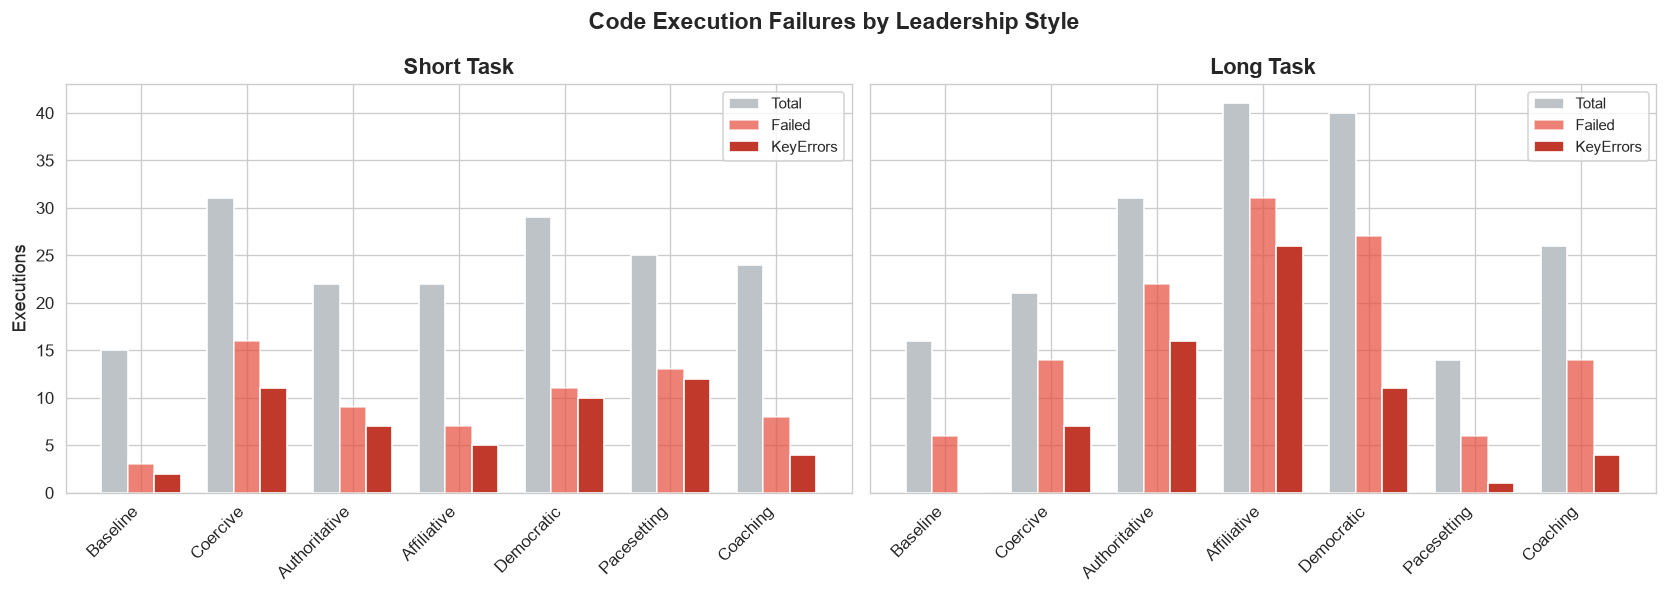

In [64]:
# Failure rate by style × task
ce_agg = ce_df.groupby(['style', 'task']).agg(
    total=('total_execs', 'sum'),
    failed=('failed_execs', 'sum'),
    keyerrors=('keyerror_execs', 'sum'),
).reset_index()
ce_agg['fail_rate'] = (ce_agg['failed'] / ce_agg['total'] * 100).round(1)
ce_agg['ke_rate']   = (ce_agg['keyerrors'] / ce_agg['total'] * 100).round(1)

print('Code Execution Failure Rate by Style × Task:\n')
print(ce_agg[['style', 'task', 'total', 'failed', 'keyerrors', 'fail_rate', 'ke_rate']]
      .to_string(index=False))

# Bar chart: total vs failed vs KeyError by style
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for i, task in enumerate(TASK_TYPES):
    ax = axes[i]
    task_data = ce_agg[ce_agg['task'] == task].copy()
    task_data = task_data.set_index('style').reindex(STYLE_ORDER)

    x = np.arange(len(STYLE_ORDER))
    w = 0.25

    ax.bar(x - w, task_data['total'],     w, label='Total', color='#BDC3C7', edgecolor='white')
    ax.bar(x,     task_data['failed'],    w, label='Failed', color='#E74C3C', alpha=0.7, edgecolor='white')
    ax.bar(x + w, task_data['keyerrors'], w, label='KeyErrors', color='#C0392B', edgecolor='white')

    ax.set_title(f'{task.title()} Task', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([s.title() for s in STYLE_ORDER], rotation=45, ha='right')
    ax.set_ylabel('Executions' if i == 0 else '')
    ax.legend(loc='upper right', fontsize=9)

fig.suptitle('Code Execution Failures by Leadership Style', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

### §1e2 — Code Executions vs Max Budget

In [65]:
# Code executions vs max budget (excluding exploration runs)
#
# Each coder.respond() call triggers:
#   1. A mandatory data exploration script (fingerprint: "=== DATASET STRUCTURE ===")
#   2. Up to max_retries (default 3) actual code attempts
#
# The exploration runs are auto-injected and should NOT count toward the budget.
# max_retries=3 per coder call, and coder is called in phases 3 and 6 (+ extensions).
# With 2 revision rounds: phase 3 (initial) + up to 2 extensions + phase 6 = up to 4 calls
# => theoretical max actual executions = 4 calls × 3 retries = 12, but typically ~3-9.

EXPLORATION_FINGERPRINT = '=== DATASET STRUCTURE ==='
MAX_RETRIES_PER_CALL = 3

exec_budget_rows = []

for _, run in df.iterrows():
    folder = RESULTS_DIR / run['folder']
    executions = load_jsonl(folder / 'code_executions.jsonl')

    total_execs = len(executions)
    exploration_execs = 0
    actual_execs = 0
    actual_failed = 0
    actual_success = 0

    for ex in executions:
        code = ex.get('code', '')
        stdout = ex.get('stdout', '') or ''
        # Exploration scripts print "=== DATASET STRUCTURE ===" and are short fixed scripts
        if EXPLORATION_FINGERPRINT in stdout or EXPLORATION_FINGERPRINT in code:
            exploration_execs += 1
        else:
            actual_execs += 1
            if ex.get('success', False):
                actual_success += 1
            else:
                actual_failed += 1

    # Number of coder calls = coder_calls from metadata
    coder_calls = run.get('coder_calls', 0)
    # Max actual executions = coder_calls * max_retries (exploration not counted)
    max_actual_execs = coder_calls * MAX_RETRIES_PER_CALL

    exec_budget_rows.append({
        'folder':           run['folder'],
        'style':            run['style'],
        'task':             run['task'],
        'run_id':           run['run_id'],
        'total_execs':      total_execs,
        'exploration_execs': exploration_execs,
        'actual_execs':     actual_execs,
        'actual_success':   actual_success,
        'actual_failed':    actual_failed,
        'coder_calls':      coder_calls,
        'max_actual_execs': max_actual_execs,
        'budget_used_pct':  (actual_execs / max_actual_execs * 100) if max_actual_execs > 0 else 0,
        'hit_max_budget':   actual_execs >= max_actual_execs,
    })

eb_df = pd.DataFrame(exec_budget_rows)

# Overall summary
print('=== Code Execution Budget Summary ===')
print(f'Total executions across all runs:  {eb_df["total_execs"].sum()}')
print(f'  Exploration (auto, not counted): {eb_df["exploration_execs"].sum()}')
print(f'  Actual code attempts:            {eb_df["actual_execs"].sum()}')
print(f'    Successful:                    {eb_df["actual_success"].sum()}')
print(f'    Failed:                        {eb_df["actual_failed"].sum()}')
print()

# Budget usage stats
print(f'Mean actual execs per run:  {eb_df["actual_execs"].mean():.1f}')
print(f'Mean budget used:           {eb_df["budget_used_pct"].mean():.0f}%')
print(f'Runs that hit max budget:   {eb_df["hit_max_budget"].sum()}/{len(eb_df)}')
print()

# By task
for task in TASK_TYPES:
    subset = eb_df[eb_df['task'] == task]
    print(f'--- {task.upper()} TASK ---')
    print(f'  Mean actual execs:  {subset["actual_execs"].mean():.1f}')
    print(f'  Mean budget used:   {subset["budget_used_pct"].mean():.0f}%')
    print(f'  Hit max budget:     {subset["hit_max_budget"].sum()}/{len(subset)}')
    print(f'  Mean exploration:   {subset["exploration_execs"].mean():.1f}')
    print()

# By style × task table
budget_table = eb_df.groupby(['style', 'task']).agg(
    mean_actual=('actual_execs', 'mean'),
    mean_budget_pct=('budget_used_pct', 'mean'),
    hit_max=('hit_max_budget', 'sum'),
).round(1)

print('=== Budget Usage by Style × Task ===')
print(budget_table.to_string())

=== Code Execution Budget Summary ===
Total executions across all runs:  357
  Exploration (auto, not counted): 4
  Actual code attempts:            353
    Successful:                    170
    Failed:                        183

Mean actual execs per run:  5.0
Mean budget used:           17%
Runs that hit max budget:   0/70

--- SHORT TASK ---
  Mean actual execs:  4.7
  Mean budget used:   16%
  Hit max budget:     0/35
  Mean exploration:   0.1

--- LONG TASK ---
  Mean actual execs:  5.4
  Mean budget used:   19%
  Hit max budget:     0/35
  Mean exploration:   0.0

=== Budget Usage by Style × Task ===
                     mean_actual  mean_budget_pct  hit_max
style         task                                        
affiliative   long           8.2             20.7        0
              short          4.4             16.7        0
authoritative long           6.2             20.5        0
              short          4.4             16.2        0
baseline      long           3

### §1f — Revision Round Saturation

In [66]:
df['hit_max_revisions'] = df['revision_rounds'] >= df['max_revision_rounds']

# By task
for task in TASK_TYPES:
    subset = df[df['task'] == task]
    n_max = subset['hit_max_revisions'].sum()
    print(f'{task.title()}: {n_max}/{len(subset)} runs hit max revisions '
          f'({n_max/len(subset)*100:.0f}%)')

# By style × task
rev_table = df.groupby(['style', 'task'])['hit_max_revisions'].agg(['sum', 'count'])
rev_table['rate'] = (rev_table['sum'] / rev_table['count'] * 100).round(0).astype(int)
rev_table['display'] = rev_table.apply(
    lambda r: f"{int(r['sum'])}/{int(r['count'])} ({int(r['rate'])}%)", axis=1
)
print('\nMax Revision Saturation by Style × Task:\n')
print(rev_table['display'].unstack(fill_value='–'))

# Cross-check: are max-revision runs always truncation-affected?
both = df[df['hit_max_revisions'] & df['truncation_flagged']]
max_rev_only = df[df['hit_max_revisions'] & ~df['truncation_flagged']]
trunc_only = df[~df['hit_max_revisions'] & df['truncation_flagged']]

print(f'\nCross-check (max revisions × truncation):')
print(f'  Both max-rev AND truncated:     {len(both)}')
print(f'  Max-rev but NOT truncated:      {len(max_rev_only)}')
print(f'  Truncated but NOT max-rev:      {len(trunc_only)}')
if len(df[df['hit_max_revisions']]) > 0:
    overlap_pct = len(both) / len(df[df['hit_max_revisions']]) * 100
    print(f'  Overlap rate: {overlap_pct:.0f}% of max-rev runs are also truncated')

Short: 14/35 runs hit max revisions (40%)
Long: 32/35 runs hit max revisions (91%)

Max Revision Saturation by Style × Task:

task                 long      short
style                               
baseline        3/5 (60%)  1/5 (20%)
coercive       5/5 (100%)  3/5 (60%)
authoritative  5/5 (100%)  1/5 (20%)
affiliative    5/5 (100%)  3/5 (60%)
democratic     5/5 (100%)  2/5 (40%)
pacesetting     4/5 (80%)  2/5 (40%)
coaching       5/5 (100%)  2/5 (40%)

Cross-check (max revisions × truncation):
  Both max-rev AND truncated:     38
  Max-rev but NOT truncated:      8
  Truncated but NOT max-rev:      11
  Overlap rate: 83% of max-rev runs are also truncated


### §1g — Survey Differentiation Check

In [67]:
# Identical composite rate
n_identical = df['survey_identical'].sum()
n_with_data = df['survey_identical'].notna().sum()

print(f'Runs with identical composites (all 3 workers same score): '
      f'{n_identical}/{n_with_data} ({n_identical/n_with_data*100:.0f}%)\n')

# By style
ident_by_style = df.groupby('style')['survey_identical'].agg(['sum', 'count'])
ident_by_style['rate'] = (ident_by_style['sum'] / ident_by_style['count'] * 100).round(0)
print('Identical survey rate by style:\n')
print(ident_by_style.to_string())

# Per-question variance: which questions differentiate?
q_cols = [f'survey_{agent}_{q}'
          for q in ['q1', 'q2', 'q3', 'q4', 'q5', 'q6']
          for agent in ['coder', 'writer', 'reviewer']]

# For each run, compute std across 3 workers per question
q_var_data = []
for _, run in df.iterrows():
    for q in ['q1', 'q2', 'q3', 'q4', 'q5', 'q6']:
        vals = [
            run.get(f'survey_coder_{q}'),
            run.get(f'survey_writer_{q}'),
            run.get(f'survey_reviewer_{q}'),
        ]
        vals = [v for v in vals if v is not None and not pd.isna(v)]
        if len(vals) == 3:
            q_var_data.append({
                'question': q,
                'std': np.std(vals),
                'all_same': (vals[0] == vals[1] == vals[2]),
            })

q_var_df = pd.DataFrame(q_var_data)
print('\nPer-question differentiation (std across 3 workers, averaged over all runs):\n')
q_summary = q_var_df.groupby('question').agg(
    mean_std=('std', 'mean'),
    pct_all_same=('all_same', 'mean'),
).round(3)
q_summary['pct_all_same'] = (q_summary['pct_all_same'] * 100).round(0).astype(int)
q_summary.columns = ['Mean Std Dev', '% Runs All Same']
q_summary

Runs with identical composites (all 3 workers same score): 32/70 (46%)

Identical survey rate by style:

               sum  count  rate
style                          
baseline         2     10  20.0
coercive         2     10  20.0
authoritative    8     10  80.0
affiliative      6     10  60.0
democratic       4     10  40.0
pacesetting      2     10  20.0
coaching         8     10  80.0

Per-question differentiation (std across 3 workers, averaged over all runs):



,Mean Std Dev,% Runs All Same
question,,
q1,0.074,87
q2,0.128,74
q3,0.088,81
q4,0.159,74
q5,0.101,79
q6,0.110,83


### §1h — Anomaly Flags

In [68]:
anomalies = []

for _, run in df.iterrows():
    flags = []

    # Very short duration
    if run.get('duration_seconds') is not None and run['duration_seconds'] < 120:
        flags.append(f"Duration very short: {run['duration_seconds']:.0f}s")

    # Very few messages
    if run.get('total_messages') is not None and run['total_messages'] < 10:
        flags.append(f"Few messages: {run['total_messages']}")

    # Excessive code executions
    if run.get('total_code_execs') is not None and run['total_code_execs'] > 10:
        flags.append(f"Many code execs: {run['total_code_execs']}")

    # Zero revision rounds (might be suspicious for long tasks)
    if run['task'] == 'long' and run.get('revision_rounds') == 0:
        flags.append('Long task with 0 revisions')

    if flags:
        anomalies.append({
            'folder': run['folder'],
            'style': run['style'],
            'task': run['task'],
            'flags': '; '.join(flags),
        })

# Identical quality across reps
for style in STYLE_ORDER:
    for task in TASK_TYPES:
        subset = df[(df['style'] == style) & (df['task'] == task)]
        if len(subset) >= 2 and subset['quality_mean'].notna().all():
            if subset['quality_mean'].nunique() == 1:
                anomalies.append({
                    'folder': f'{style}_{task}_*',
                    'style': style,
                    'task': task,
                    'flags': f"Identical quality_mean across all {len(subset)} reps: {subset['quality_mean'].iloc[0]}",
                })

anom_df = pd.DataFrame(anomalies)

if len(anom_df) > 0:
    print(f'⚠️ {len(anom_df)} anomalies detected:\n')
    for _, a in anom_df.iterrows():
        print(f"  {a['folder']}: {a['flags']}")
else:
    print('✅ No anomalies detected.')

⚠️ 2 anomalies detected:

  affiliative_long_run01: Many code execs: 13
  democratic_long_run04: Many code execs: 12


### §1 Summary — Issue Dashboard

In [69]:
# Consolidated issue summary
print('=' * 70)
print('HEALTH CHECK SUMMARY')
print('=' * 70)
print()

# Completeness
expected = len(STYLE_ORDER) * len(TASK_TYPES) * N_REPS
status = '✅' if len(df) == expected else '⚠️'
print(f'{status} Completeness: {len(df)}/{expected} runs found')

# Truncation
n_trunc = df['truncation_flagged'].sum()
status = '✅' if n_trunc == 0 else '🔴' if n_trunc > len(df) * 0.3 else '⚠️'
print(f'{status} Truncation: {n_trunc}/{len(df)} runs flagged ({n_trunc/len(df)*100:.0f}%)')
for task in TASK_TYPES:
    sub = df[df['task'] == task]
    n = sub['truncation_flagged'].sum()
    print(f'     {task}: {n}/{len(sub)} ({n/len(sub)*100:.0f}%)')

# KeyErrors
status = '✅' if total_ke == 0 else '🔴' if total_ke > 50 else '⚠️'
print(f'{status} KeyErrors: {total_ke} across {total_execs} code executions '
      f'({total_ke/total_execs*100:.1f}%)')

# Code execution failures
fail_rate = total_failed / total_execs * 100
status = '✅' if fail_rate < 10 else '🔴' if fail_rate > 40 else '⚠️'
print(f'{status} Code execution failure rate: {fail_rate:.1f}%')

# Revision saturation
n_maxrev = df['hit_max_revisions'].sum()
status = '✅' if n_maxrev < len(df) * 0.3 else '🔴'
print(f'{status} Max revision saturation: {n_maxrev}/{len(df)} runs '
      f'({n_maxrev/len(df)*100:.0f}%)')

# Survey differentiation
status = '✅' if n_identical < n_with_data * 0.2 else '⚠️' if n_identical < n_with_data * 0.5 else '🔴'
print(f'{status} Survey identical composites: {n_identical}/{n_with_data} '
      f'({n_identical/n_with_data*100:.0f}%)')

# Anomalies
n_anom = len(anom_df) if len(anom_df) > 0 else 0
status = '✅' if n_anom == 0 else '⚠️'
print(f'{status} Anomalies: {n_anom} flagged')

# Sentiment
mean_sent = df['sentiment_mean'].mean()
print(f'ℹ️  Mean sentiment (compound): {mean_sent:.3f} (expected positive skew for VADER)')

print()
print('=' * 70)
print('Proceed to §2 (Output Quality) ↓')
print('=' * 70)

HEALTH CHECK SUMMARY

✅ Completeness: 70/70 runs found
🔴 Truncation: 49/70 runs flagged (70%)
     short: 18/35 (51%)
     long: 31/35 (89%)
🔴 KeyErrors: 116 across 6 code executions (1933.3%)
🔴 Code execution failure rate: 3116.7%
🔴 Max revision saturation: 46/70 runs (66%)
⚠️ Survey identical composites: 32/70 (46%)
⚠️ Anomalies: 2 flagged
ℹ️  Mean sentiment (compound): 0.666 (expected positive skew for VADER)

Proceed to §2 (Output Quality) ↓


---
## §2 — DV 1: Output Quality

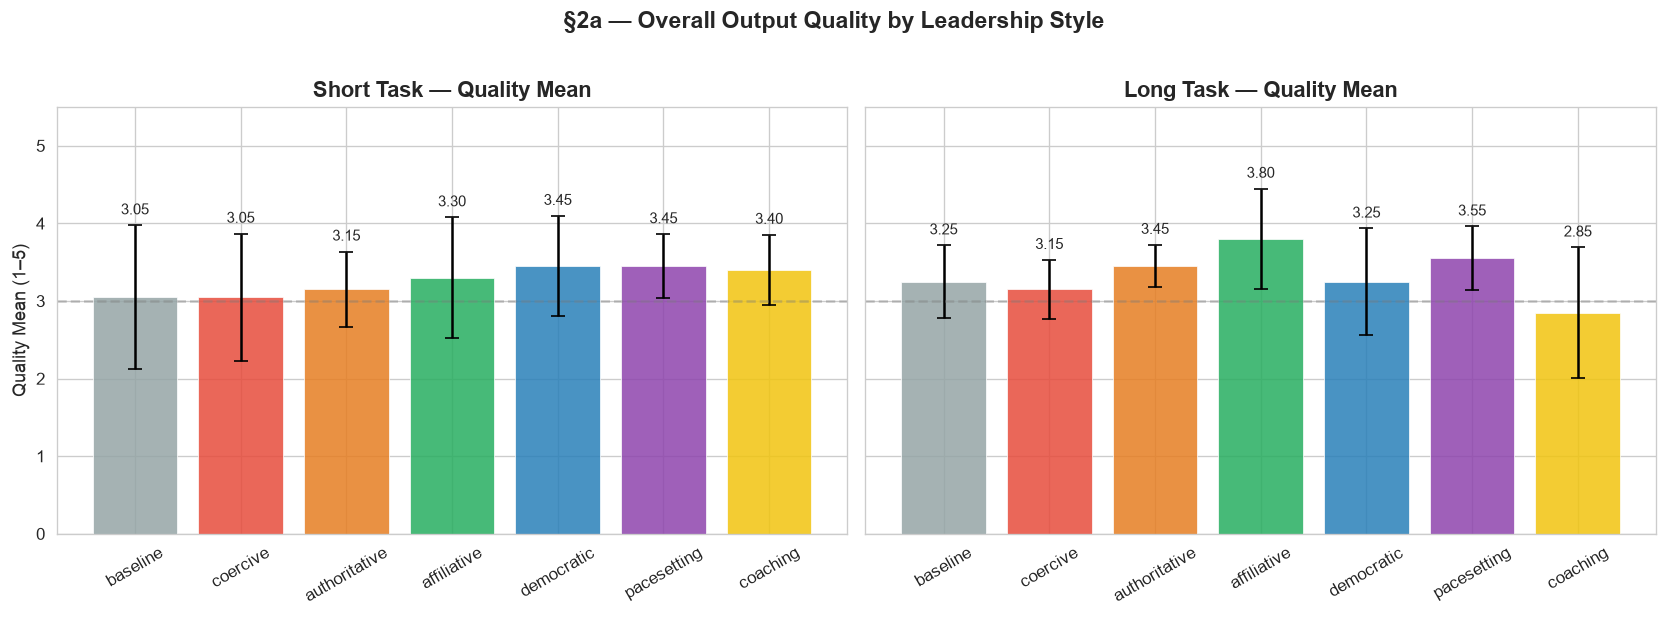

In [70]:
# §2a: Overall quality by style

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, task in zip(axes, TASK_TYPES):
    sub = df[df['task'] == task]
    means = sub.groupby('style', observed=True)['quality_mean'].mean()
    stds  = sub.groupby('style', observed=True)['quality_mean'].std()
    colors = [STYLE_COLORS[s] for s in means.index]

    bars = ax.bar(means.index, means, yerr=stds, capsize=4,
                  color=colors, edgecolor='white', linewidth=0.5, alpha=0.85)
    ax.set_title(f'{task.title()} Task — Quality Mean', fontweight='bold')
    ax.set_ylabel('Quality Mean (1–5)' if task == 'short' else '')
    ax.set_ylim(0, 5.5)
    ax.axhline(y=3, color='gray', linestyle='--', alpha=0.4, label='Midpoint')
    ax.tick_params(axis='x', rotation=30)

    # Value labels on bars
    for bar, m, s in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 0.1,
                f'{m:.2f}', ha='center', va='bottom', fontsize=9)

fig.suptitle('§2a — Overall Output Quality by Leadership Style', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

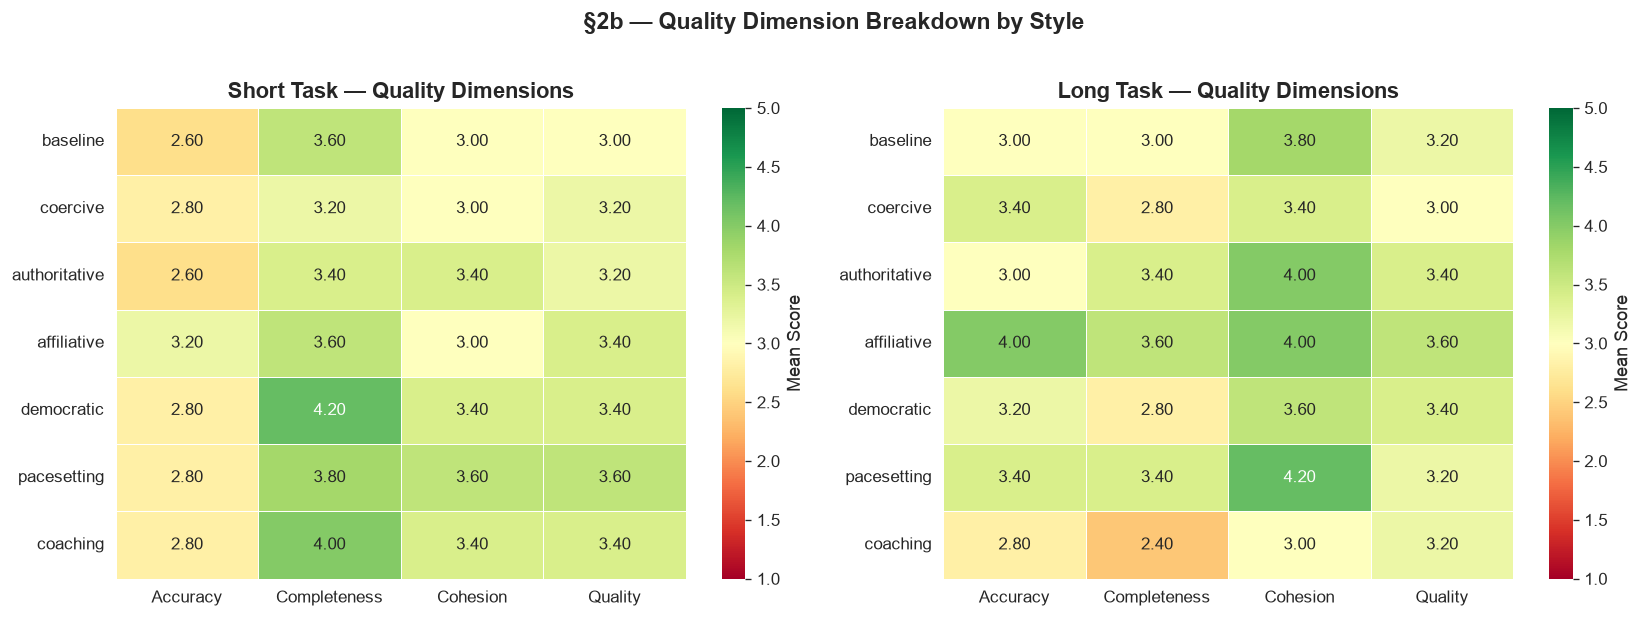

In [71]:
# §2b: Quality dimensions heatmap

dim_cols = ['score_accuracy', 'score_completeness', 'score_cohesion', 'score_quality']
dim_labels = ['Accuracy', 'Completeness', 'Cohesion', 'Quality']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, task in zip(axes, TASK_TYPES):
    sub = df[df['task'] == task]
    pivot = sub.groupby('style', observed=True)[dim_cols].mean()
    pivot.columns = dim_labels
    pivot = pivot.reindex(STYLE_ORDER)

    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', vmin=1, vmax=5,
                linewidths=0.5, ax=ax, cbar_kws={'label': 'Mean Score'})
    ax.set_title(f'{task.title()} Task — Quality Dimensions', fontweight='bold')
    ax.set_ylabel('')
    ax.set_xlabel('')

fig.suptitle('§2b — Quality Dimension Breakdown by Style', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

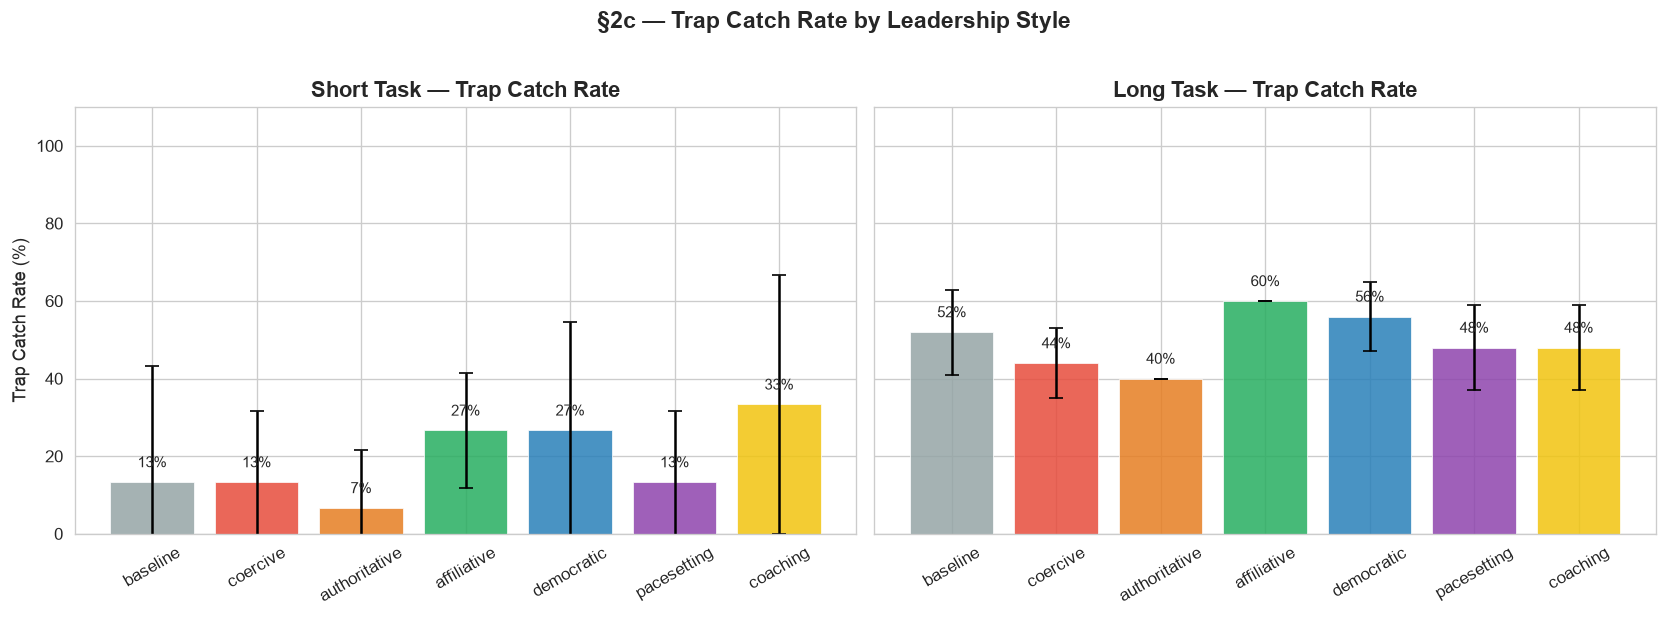

In [72]:
# §2c: Trap detection

# Overall trap catch rate by style
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, task in zip(axes, TASK_TYPES):
    sub = df[df['task'] == task]
    means = sub.groupby('style', observed=True)['trap_catch_rate'].mean()
    stds  = sub.groupby('style', observed=True)['trap_catch_rate'].std()
    colors = [STYLE_COLORS[s] for s in means.index]

    bars = ax.bar(means.index, means * 100, yerr=stds * 100, capsize=4,
                  color=colors, edgecolor='white', linewidth=0.5, alpha=0.85)
    ax.set_title(f'{task.title()} Task — Trap Catch Rate', fontweight='bold')
    ax.set_ylabel('Trap Catch Rate (%)' if task == 'short' else '')
    ax.set_ylim(0, 110)
    ax.tick_params(axis='x', rotation=30)

    for bar, m in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                f'{m*100:.0f}%', ha='center', va='bottom', fontsize=9)

fig.suptitle('§2c — Trap Catch Rate by Leadership Style', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

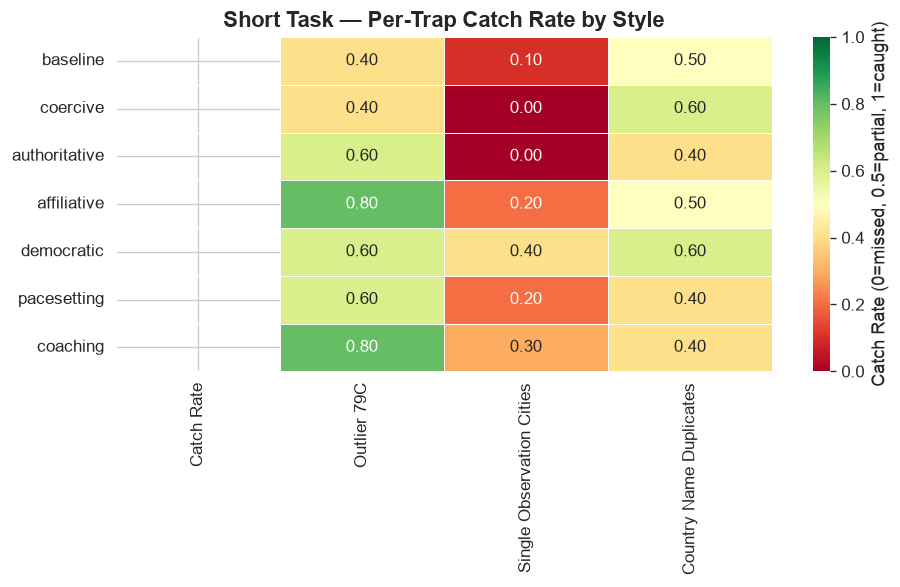

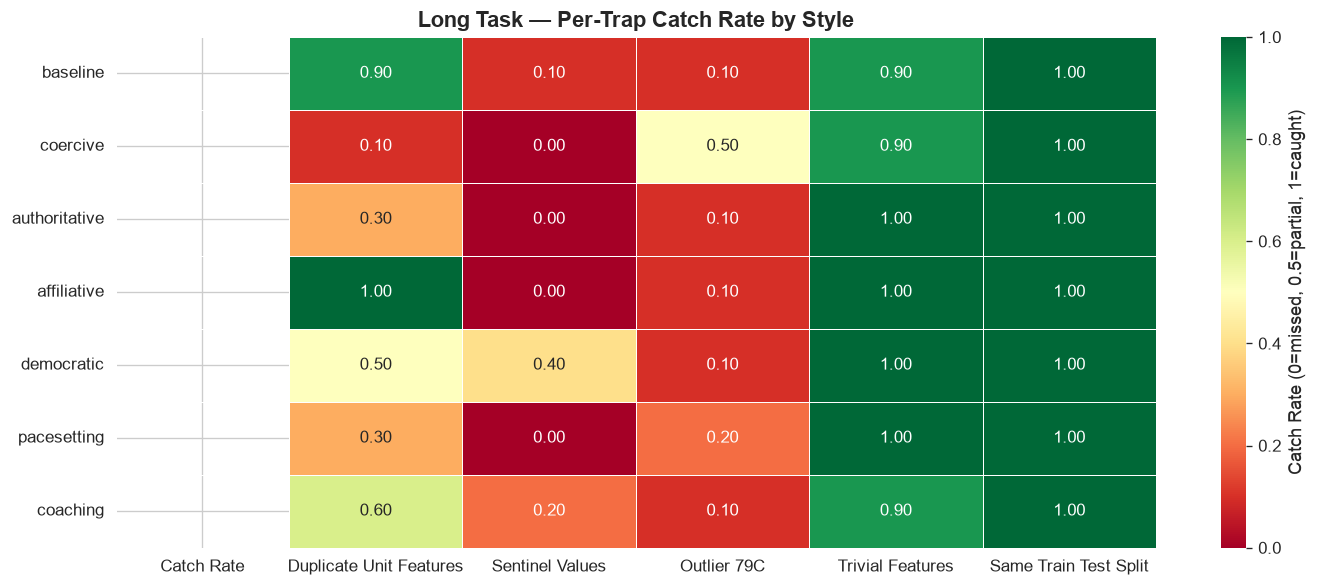

In [73]:
# §2c (cont.): Per-trap heatmaps

# Identify trap columns per task type
short_traps = [c for c in df.columns if c.startswith('trap_') and
               df.loc[df['task'] == 'short', c].notna().any()]
long_traps  = [c for c in df.columns if c.startswith('trap_') and
               df.loc[df['task'] == 'long', c].notna().any()]

def trap_status_to_score(status):
    """Convert trap status to numeric: caught=1, partial=0.5, missed=0."""
    mapping = {'caught': 1.0, 'partial': 0.5, 'missed': 0.0}
    return mapping.get(str(status).lower(), np.nan)

for task, trap_cols in [('short', short_traps), ('long', long_traps)]:
    if not trap_cols:
        print(f'No trap columns found for {task} task.')
        continue

    sub = df[df['task'] == task].copy()
    for col in trap_cols:
        sub[col + '_score'] = sub[col].apply(trap_status_to_score)

    score_cols = [c + '_score' for c in trap_cols]
    trap_labels = [c.replace('trap_', '').replace('_', ' ').title() for c in trap_cols]

    pivot = sub.groupby('style', observed=True)[score_cols].mean()
    pivot.columns = trap_labels
    pivot = pivot.reindex(STYLE_ORDER)

    fig, ax = plt.subplots(figsize=(max(8, len(trap_cols) * 2), 5))
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=1,
                linewidths=0.5, ax=ax, cbar_kws={'label': 'Catch Rate (0=missed, 0.5=partial, 1=caught)'})
    ax.set_title(f'{task.title()} Task — Per-Trap Catch Rate by Style', fontweight='bold')
    ax.set_ylabel('')
    plt.tight_layout()
    plt.show()

---
## §3 — DV 2: Efficiency

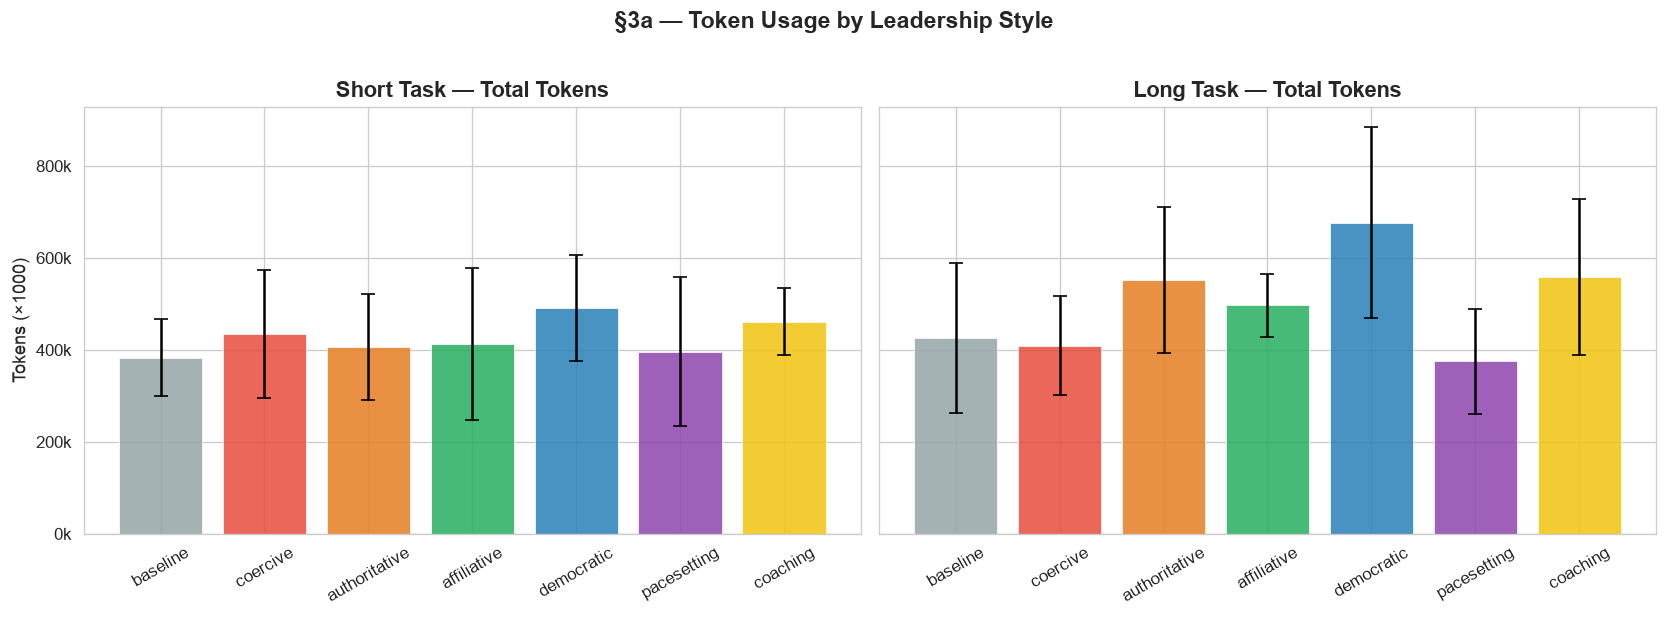

In [74]:
# §3a: Token usage by style

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, task in zip(axes, TASK_TYPES):
    sub = df[df['task'] == task]
    means = sub.groupby('style', observed=True)['total_tokens'].mean()
    stds  = sub.groupby('style', observed=True)['total_tokens'].std()
    colors = [STYLE_COLORS[s] for s in means.index]

    bars = ax.bar(means.index, means / 1000, yerr=stds / 1000, capsize=4,
                  color=colors, edgecolor='white', linewidth=0.5, alpha=0.85)
    ax.set_title(f'{task.title()} Task — Total Tokens', fontweight='bold')
    ax.set_ylabel('Tokens (×1000)' if task == 'short' else '')
    ax.tick_params(axis='x', rotation=30)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k'))

fig.suptitle('§3a — Token Usage by Leadership Style', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

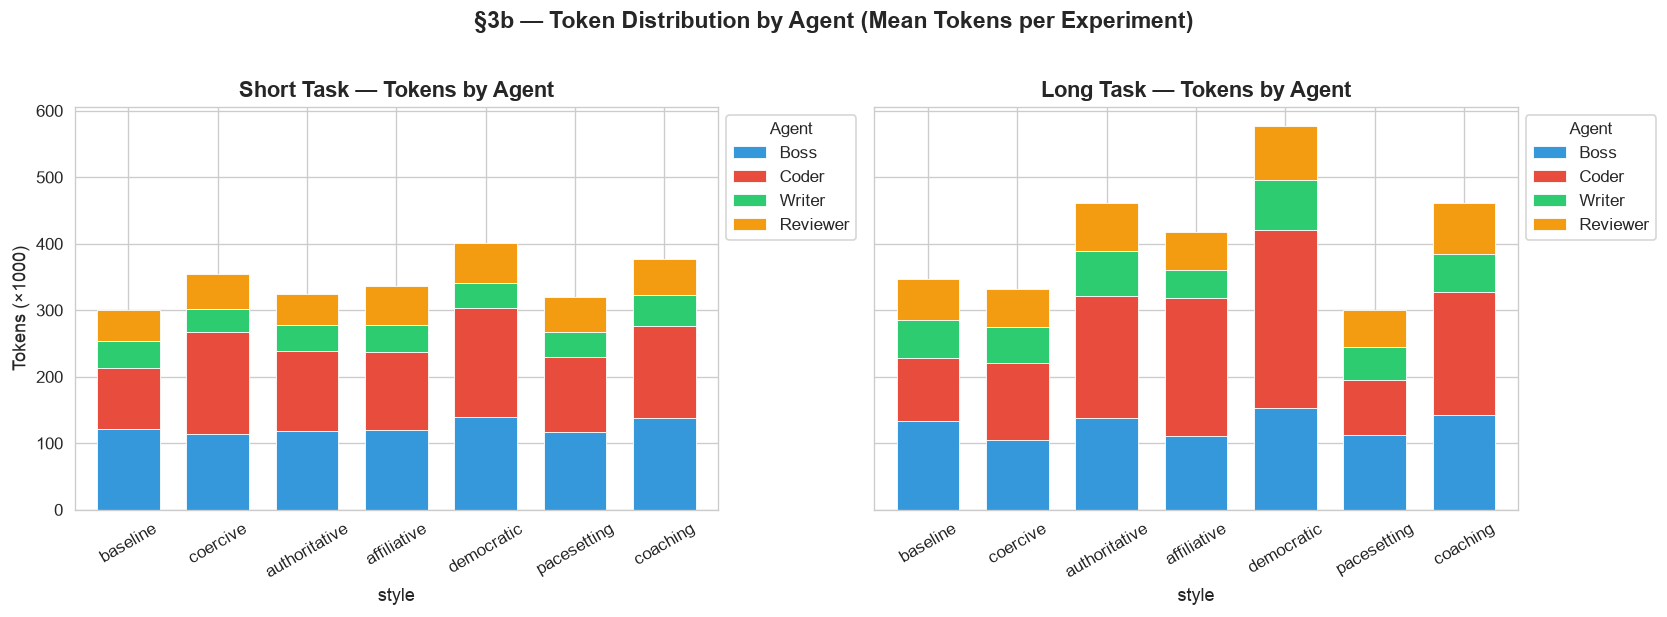

In [75]:
# §3b: Token usage by agent (stacked bar)

agent_token_cols = ['boss_tokens', 'coder_tokens', 'writer_tokens', 'reviewer_tokens']
agent_labels = ['Boss', 'Coder', 'Writer', 'Reviewer']
agent_colors = ['#3498DB', '#E74C3C', '#2ECC71', '#F39C12']

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, task in zip(axes, TASK_TYPES):
    sub = df[df['task'] == task]
    pivot = sub.groupby('style', observed=True)[agent_token_cols].mean()
    pivot.columns = agent_labels
    pivot = pivot.reindex(STYLE_ORDER)

    pivot.div(1000).plot(kind='bar', stacked=True, ax=ax, color=agent_colors,
                         edgecolor='white', linewidth=0.5, width=0.7)
    ax.set_title(f'{task.title()} Task — Tokens by Agent', fontweight='bold')
    ax.set_ylabel('Tokens (×1000)' if task == 'short' else '')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='Agent', bbox_to_anchor=(1.0, 1.0), loc='upper left')

fig.suptitle('§3b — Token Distribution by Agent (Mean Tokens per Experiment)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

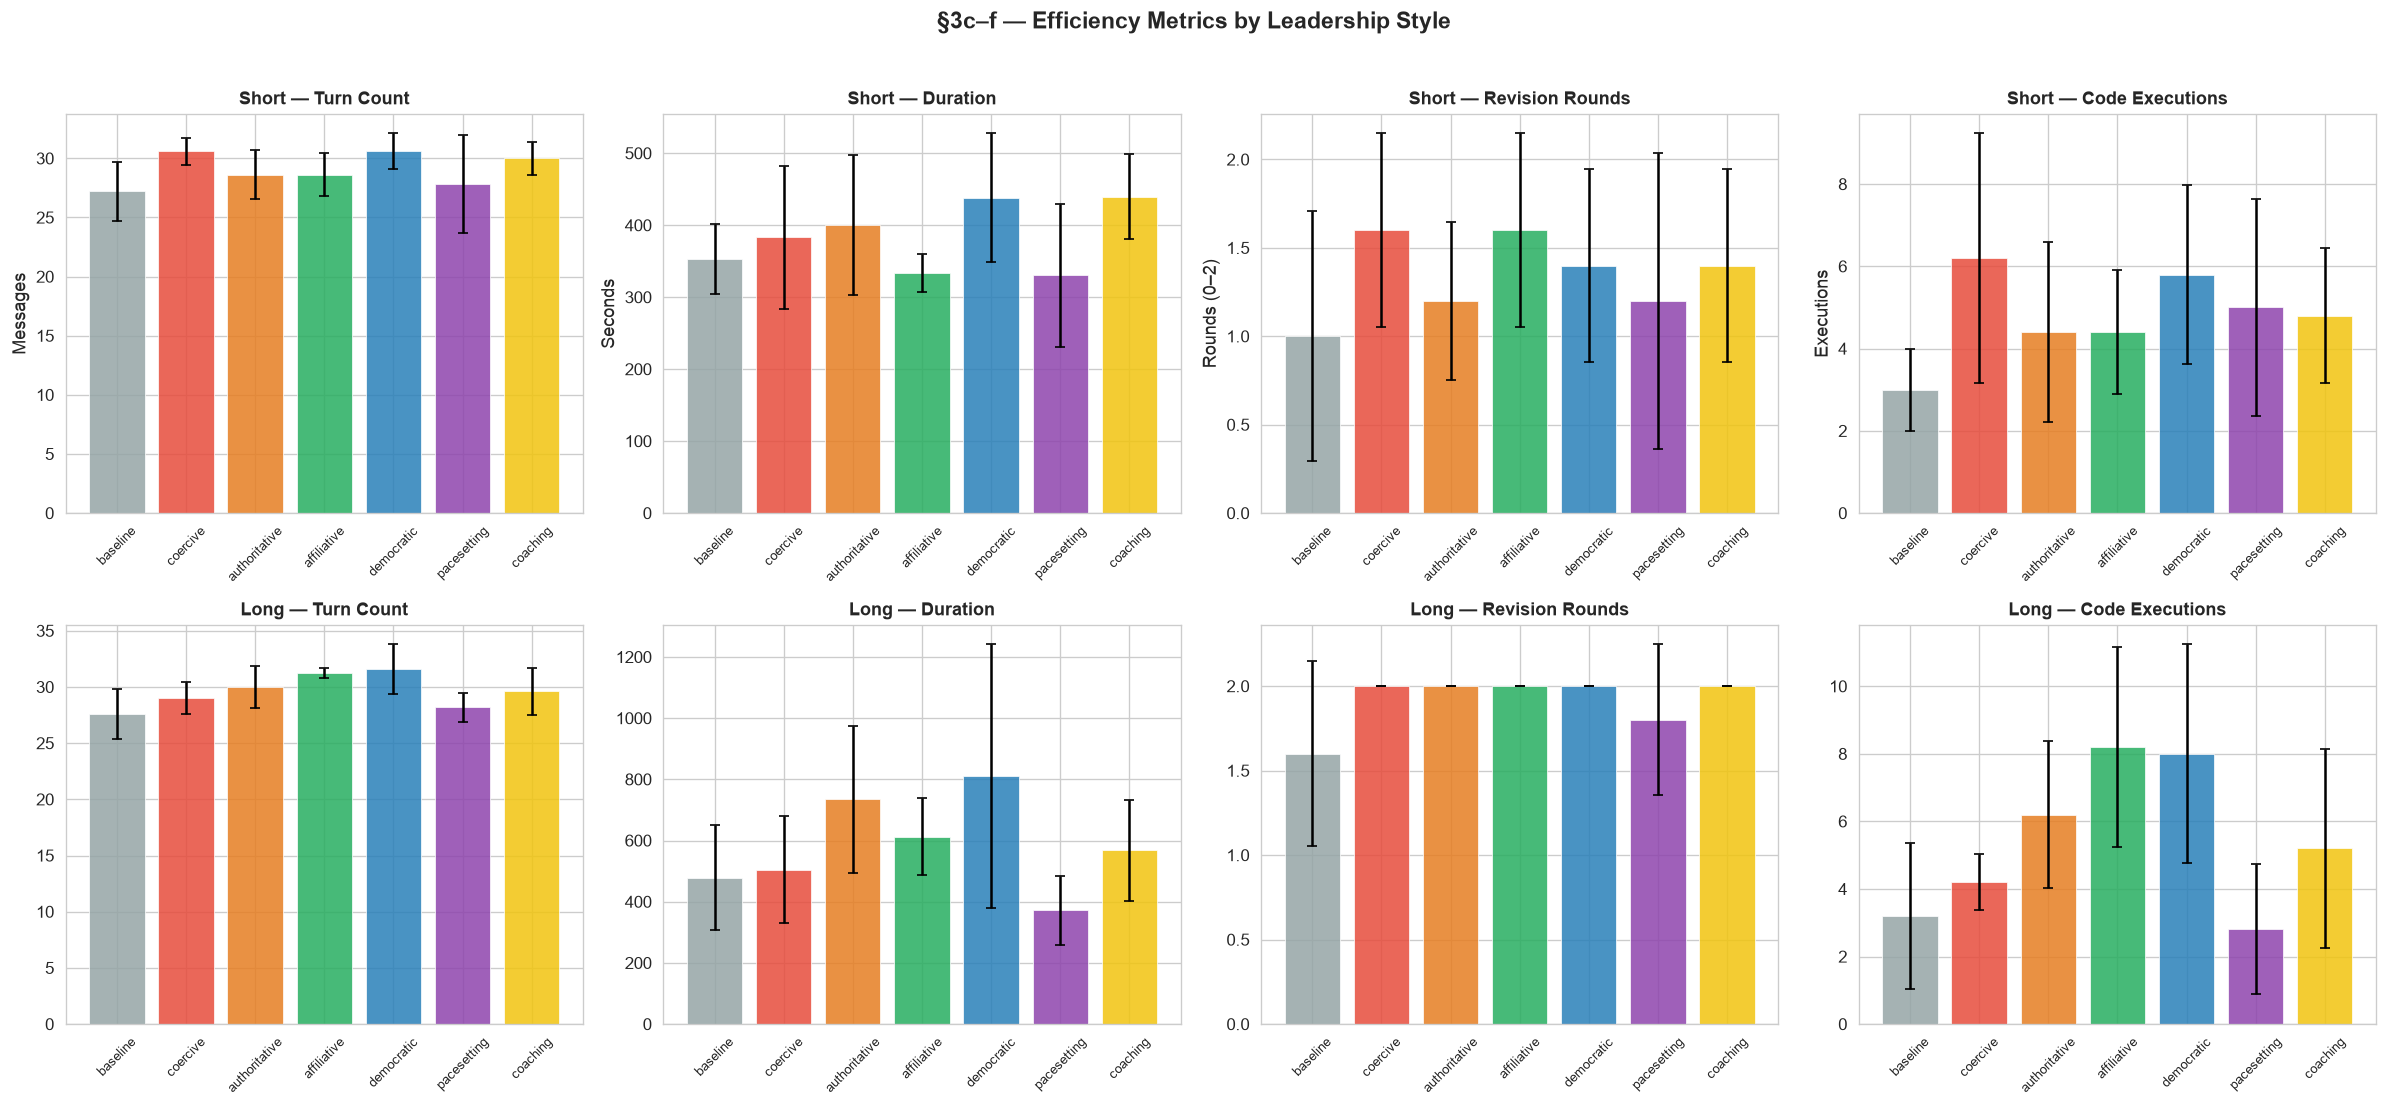

In [76]:
# §3c–§3f: Turn count, Duration, Revision rounds, Code executions

metrics = [
    ('total_messages',   'Turn Count',       'Messages'),
    ('duration_seconds', 'Duration',         'Seconds'),
    ('revision_rounds',  'Revision Rounds',  'Rounds (0–2)'),
    ('total_code_execs', 'Code Executions',  'Executions'),
]

fig, axes = plt.subplots(2, 4, figsize=(20, 9))

for col_idx, (metric, label, ylabel) in enumerate(metrics):
    for row_idx, task in enumerate(TASK_TYPES):
        ax = axes[row_idx, col_idx]
        sub = df[df['task'] == task]
        means = sub.groupby('style', observed=True)[metric].mean()
        stds  = sub.groupby('style', observed=True)[metric].std()
        colors = [STYLE_COLORS[s] for s in means.index]

        bars = ax.bar(means.index, means, yerr=stds, capsize=3,
                      color=colors, edgecolor='white', linewidth=0.5, alpha=0.85)
        ax.set_title(f'{task.title()} — {label}', fontsize=11, fontweight='bold')
        ax.set_ylabel(ylabel if task == 'short' else '')
        ax.tick_params(axis='x', rotation=45, labelsize=8)

fig.suptitle('§3c–f — Efficiency Metrics by Leadership Style', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## §4 — DV 4: Worker Satisfaction

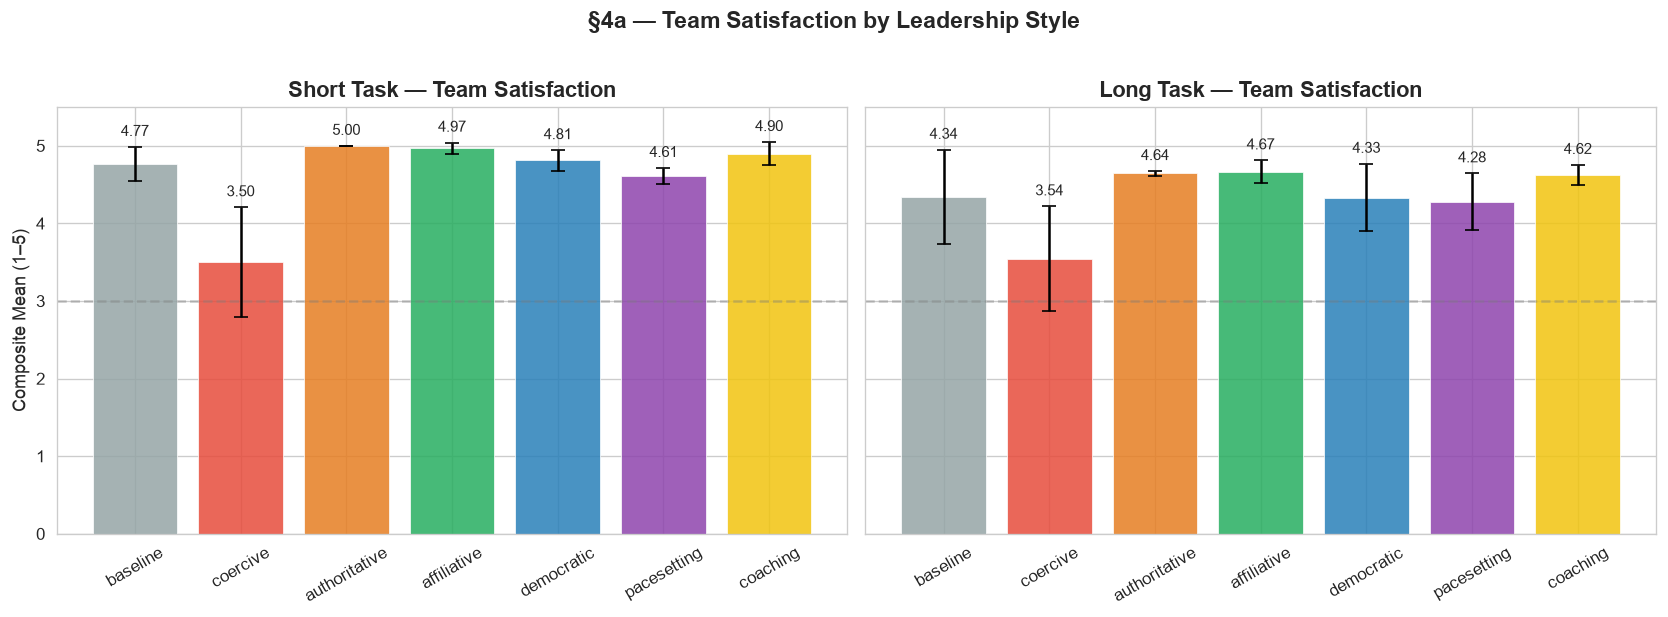

In [77]:
# §4a: Team satisfaction by style

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, task in zip(axes, TASK_TYPES):
    sub = df[df['task'] == task]
    means = sub.groupby('style', observed=True)['survey_team_mean'].mean()
    stds  = sub.groupby('style', observed=True)['survey_team_mean'].std()
    colors = [STYLE_COLORS[s] for s in means.index]

    bars = ax.bar(means.index, means, yerr=stds, capsize=4,
                  color=colors, edgecolor='white', linewidth=0.5, alpha=0.85)
    ax.set_title(f'{task.title()} Task — Team Satisfaction', fontweight='bold')
    ax.set_ylabel('Composite Mean (1–5)' if task == 'short' else '')
    ax.set_ylim(0, 5.5)
    ax.axhline(y=3, color='gray', linestyle='--', alpha=0.4)
    ax.tick_params(axis='x', rotation=30)

    for bar, m, s in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 0.1,
                f'{m:.2f}', ha='center', va='bottom', fontsize=9)

fig.suptitle('§4a — Team Satisfaction by Leadership Style', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

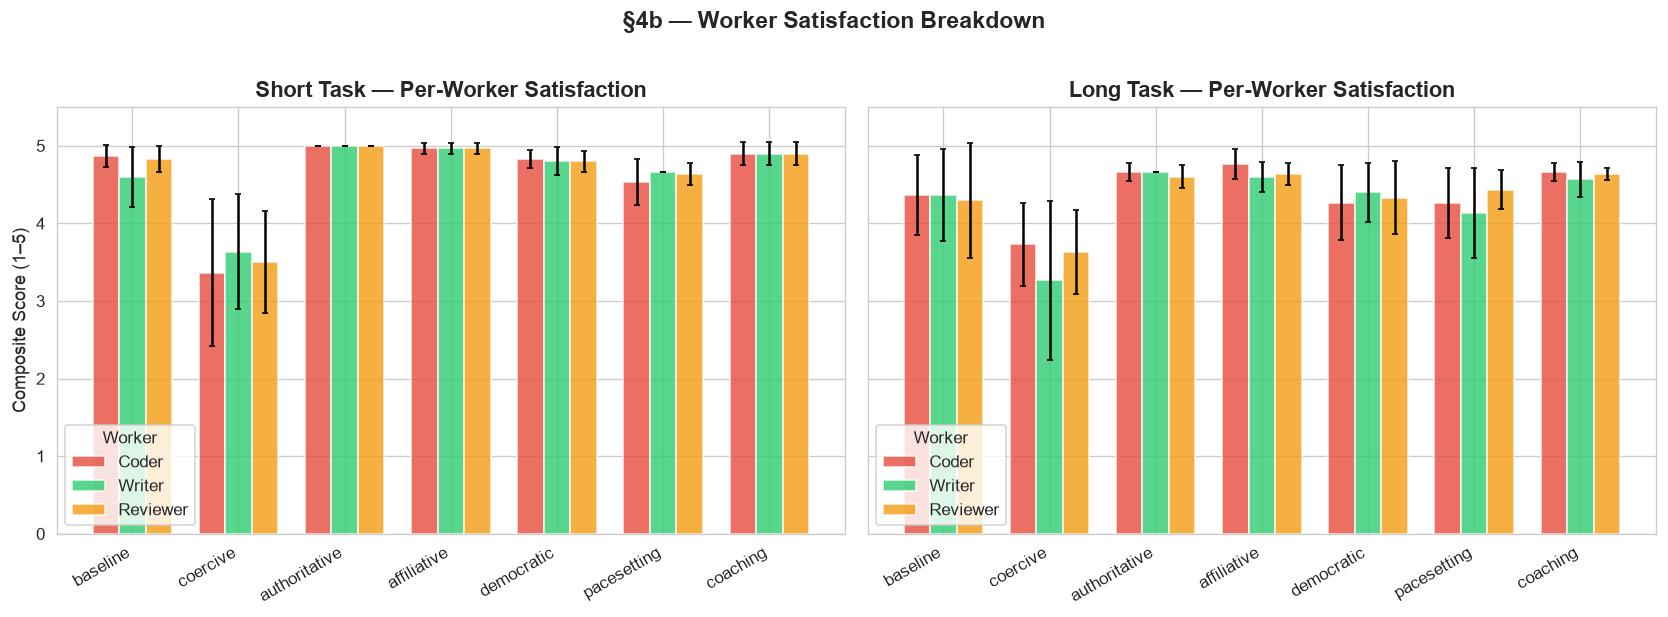

In [78]:
# §4b: Per-worker satisfaction

worker_cols = ['survey_coder', 'survey_writer', 'survey_reviewer']
worker_labels = ['Coder', 'Writer', 'Reviewer']
worker_colors = ['#E74C3C', '#2ECC71', '#F39C12']

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, task in zip(axes, TASK_TYPES):
    sub = df[df['task'] == task]
    x = np.arange(len(STYLE_ORDER))
    width = 0.25

    for i, (col, label, color) in enumerate(zip(worker_cols, worker_labels, worker_colors)):
        means = sub.groupby('style', observed=True)[col].mean().reindex(STYLE_ORDER)
        stds  = sub.groupby('style', observed=True)[col].std().reindex(STYLE_ORDER)
        ax.bar(x + i * width, means, width, yerr=stds, capsize=2,
               label=label, color=color, alpha=0.8, edgecolor='white')

    ax.set_xticks(x + width)
    ax.set_xticklabels(STYLE_ORDER, rotation=30, ha='right')
    ax.set_title(f'{task.title()} Task — Per-Worker Satisfaction', fontweight='bold')
    ax.set_ylabel('Composite Score (1–5)' if task == 'short' else '')
    ax.set_ylim(0, 5.5)
    ax.legend(title='Worker')

fig.suptitle('§4b — Worker Satisfaction Breakdown', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

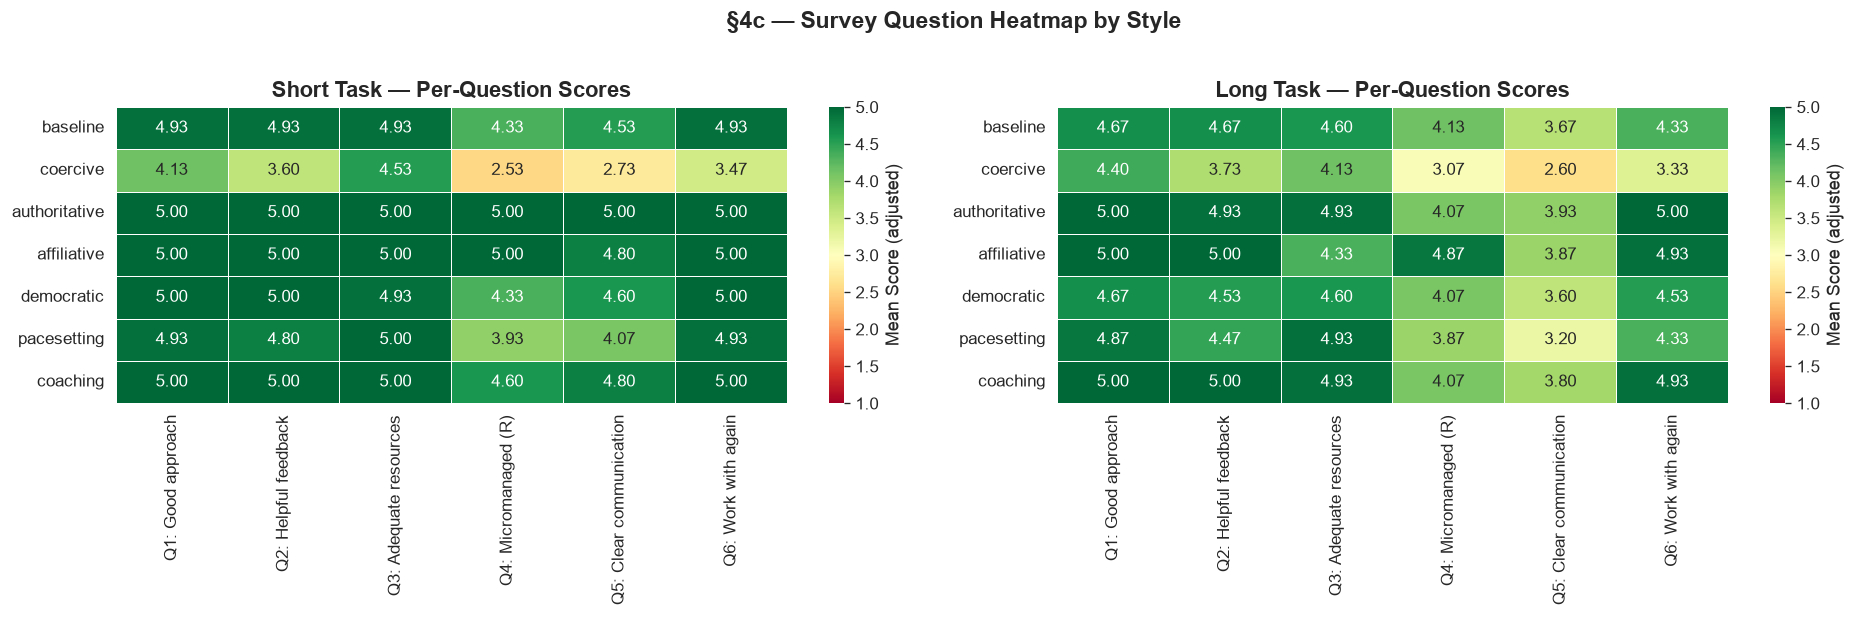

In [79]:
# §4c: Per-question heatmap

# Average across all three workers for each question
q_cols = ['q1', 'q2', 'q3', 'q4', 'q5', 'q6']
q_labels = [
    'Q1: Good approach',
    'Q2: Helpful feedback',
    'Q3: Adequate resources',
    'Q4: Micromanaged (R)',
    'Q5: Clear communication',
    'Q6: Work with again',
]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, task in zip(axes, TASK_TYPES):
    sub = df[df['task'] == task].copy()

    # Average each question across the three workers
    for q in q_cols:
        worker_q_cols = [f'survey_{w}_{q}' for w in ['coder', 'writer', 'reviewer']]
        existing = [c for c in worker_q_cols if c in sub.columns]
        if existing:
            sub[f'avg_{q}'] = sub[existing].mean(axis=1)

    avg_q_cols = [f'avg_{q}' for q in q_cols if f'avg_{q}' in sub.columns]
    pivot = sub.groupby('style', observed=True)[avg_q_cols].mean()
    pivot.columns = q_labels[:len(avg_q_cols)]
    pivot = pivot.reindex(STYLE_ORDER)

    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', vmin=1, vmax=5,
                linewidths=0.5, ax=ax, cbar_kws={'label': 'Mean Score (adjusted)'})
    ax.set_title(f'{task.title()} Task — Per-Question Scores', fontweight='bold')
    ax.set_ylabel('')

fig.suptitle('§4c — Survey Question Heatmap by Style', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [80]:
# §4d: Differentiation analysis

print('=== Survey Differentiation Analysis ===')
print()

# Per-question variance across styles (does this question discriminate?)
print('Per-question variance across styles (higher = more discriminating):')
for task in TASK_TYPES:
    sub = df[df['task'] == task]
    print(f'\n  {task.title()} Task:')
    for q in q_cols:
        worker_q_cols = [f'survey_{w}_{q}' for w in ['coder', 'writer', 'reviewer']]
        existing = [c for c in worker_q_cols if c in sub.columns]
        if existing:
            avg = sub[existing].mean(axis=1)
            style_means = sub.assign(avg_q=avg).groupby('style', observed=True)['avg_q'].mean()
            print(f'    {q}: between-style var = {style_means.var():.4f}, '
                  f'range = {style_means.min():.2f}–{style_means.max():.2f}')

print()

# Identical composites rate
for task in TASK_TYPES:
    sub = df[df['task'] == task]
    n_identical = sub['survey_identical'].sum()
    n_total = sub['survey_identical'].notna().sum()
    print(f'{task.title()} Task: {n_identical}/{n_total} runs ({100*n_identical/n_total:.0f}%) '
          f'have identical composites across all 3 workers')

=== Survey Differentiation Analysis ===

Per-question variance across styles (higher = more discriminating):

  Short Task:
    q1: between-style var = 0.1029, range = 4.13–5.00
    q2: between-style var = 0.2679, range = 3.60–5.00
    q3: between-style var = 0.0292, range = 4.53–5.00
    q4: between-style var = 0.7181, range = 2.53–5.00
    q5: between-style var = 0.6028, range = 2.73–5.00
    q6: between-style var = 0.3272, range = 3.47–5.00

  Long Task:
    q1: between-style var = 0.0533, range = 4.40–5.00
    q2: between-style var = 0.2011, range = 3.73–5.00
    q3: between-style var = 0.1020, range = 4.13–4.93
    q4: between-style var = 0.2781, range = 3.07–4.87
    q5: between-style var = 0.2243, range = 2.60–3.93
    q6: between-style var = 0.3403, range = 3.33–5.00

Short Task: 21/35 runs (60%) have identical composites across all 3 workers
Long Task: 11/35 runs (31%) have identical composites across all 3 workers


---
## §5 — Cross-DV Correlations

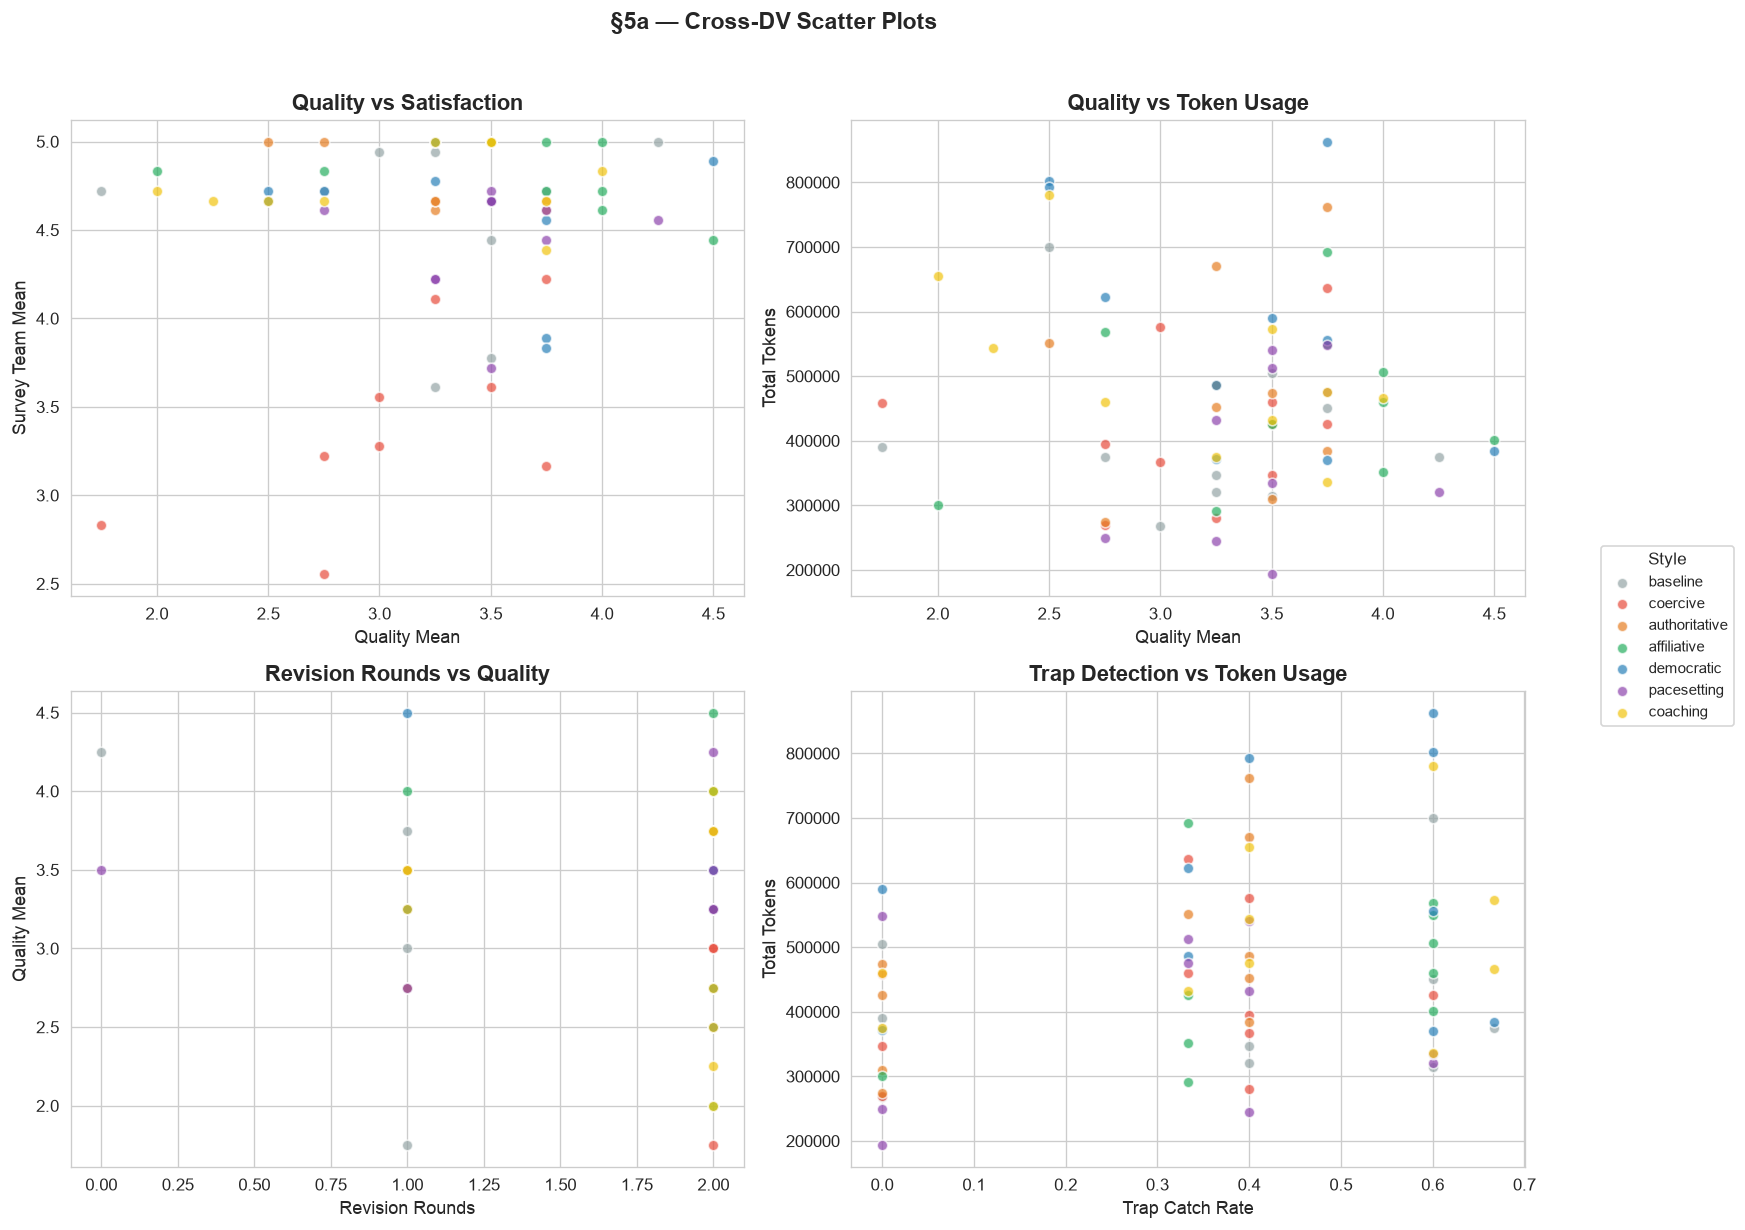

In [81]:
# §5a: Scatter plots — key relationships

scatter_pairs = [
    ('quality_mean',    'survey_team_mean', 'Quality vs Satisfaction'),
    ('quality_mean',    'total_tokens',     'Quality vs Token Usage'),
    ('revision_rounds', 'quality_mean',     'Revision Rounds vs Quality'),
    ('trap_catch_rate', 'total_tokens',     'Trap Detection vs Token Usage'),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for ax, (x_col, y_col, title) in zip(axes.flat, scatter_pairs):
    for style in STYLE_ORDER:
        sub = df[df['style'] == style]
        ax.scatter(sub[x_col], sub[y_col], label=style,
                   color=STYLE_COLORS[style], s=40, alpha=0.7, edgecolor='white')
    ax.set_xlabel(x_col.replace('_', ' ').title())
    ax.set_ylabel(y_col.replace('_', ' ').title())
    ax.set_title(title, fontweight='bold')

# Single legend for all subplots
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.12, 0.5),
           title='Style', fontsize=9)

fig.suptitle('§5a — Cross-DV Scatter Plots', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

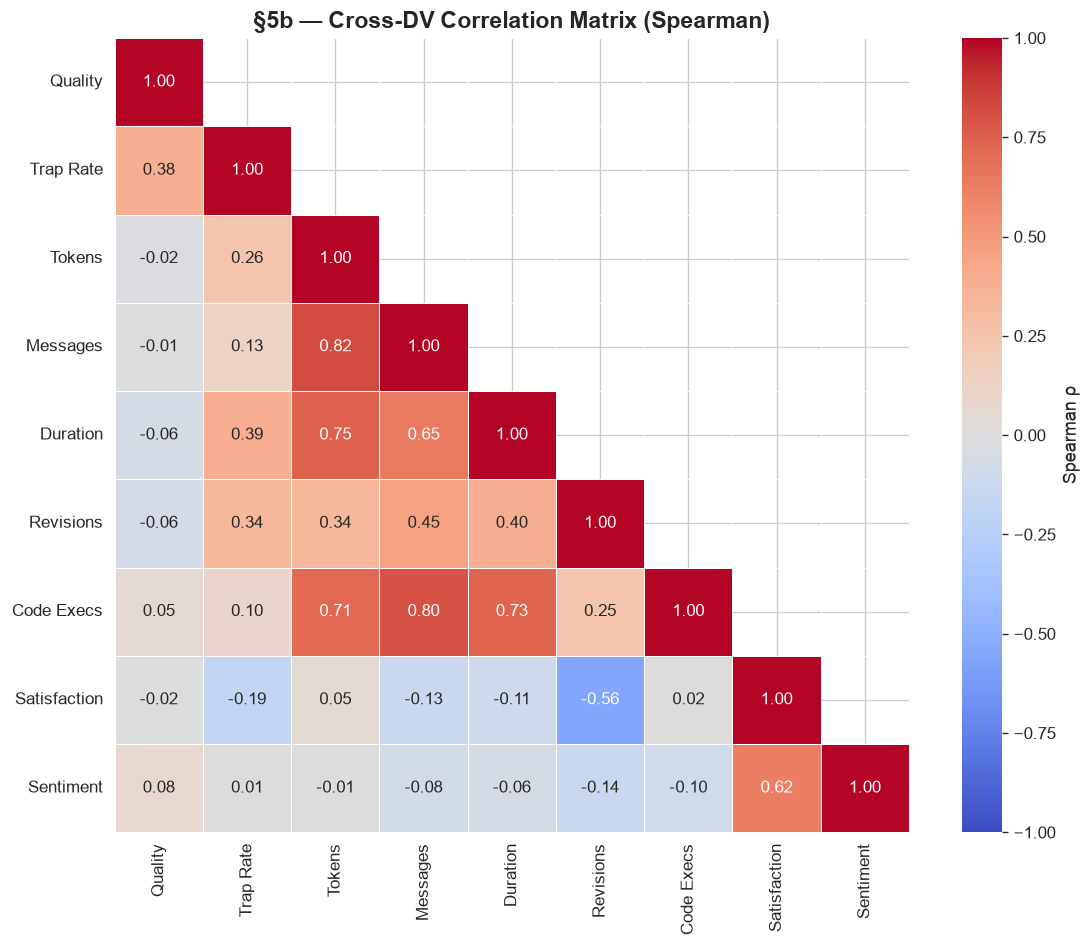


Notable correlations (|ρ| > 0.4):
  Tokens ↔ Messages: ρ = 0.824
  Tokens ↔ Duration: ρ = 0.747
  Tokens ↔ Code Execs: ρ = 0.712
  Messages ↔ Duration: ρ = 0.647
  Messages ↔ Revisions: ρ = 0.453
  Messages ↔ Code Execs: ρ = 0.804
  Duration ↔ Code Execs: ρ = 0.733
  Revisions ↔ Satisfaction: ρ = -0.559
  Satisfaction ↔ Sentiment: ρ = 0.619


In [82]:
# §5b: Correlation matrix

corr_cols = [
    'quality_mean', 'trap_catch_rate', 'total_tokens', 'total_messages',
    'duration_seconds', 'revision_rounds', 'total_code_execs',
    'survey_team_mean', 'sentiment_mean',
]
corr_labels = [
    'Quality', 'Trap Rate', 'Tokens', 'Messages',
    'Duration', 'Revisions', 'Code Execs',
    'Satisfaction', 'Sentiment',
]

# Use only columns that exist and have data
valid_cols = [c for c in corr_cols if c in df.columns and df[c].notna().any()]
valid_labels = [corr_labels[corr_cols.index(c)] for c in valid_cols]

corr = df[valid_cols].corr(method='spearman')
corr.index = valid_labels
corr.columns = valid_labels

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, mask=mask, linewidths=0.5, ax=ax,
            square=True, cbar_kws={'label': 'Spearman ρ'})
ax.set_title('§5b — Cross-DV Correlation Matrix (Spearman)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nNotable correlations (|ρ| > 0.4):')
for i in range(len(valid_labels)):
    for j in range(i+1, len(valid_labels)):
        r = corr.iloc[i, j]
        if abs(r) > 0.4:
            print(f'  {valid_labels[i]} ↔ {valid_labels[j]}: ρ = {r:.3f}')

---
## §6 — Statistical Tests

Kruskal-Wallis H-test (non-parametric) followed by pairwise Mann-Whitney U with rank-biserial effect size where significant. Note: n=5 per condition limits statistical power; effect sizes are more informative than p-values.

In [83]:
# §6: Kruskal-Wallis across styles for key metrics

def rank_biserial(group_a, group_b):
    """Compute rank-biserial effect size for Mann-Whitney U."""
    u_stat, _ = stats.mannwhitneyu(group_a, group_b, alternative='two-sided')
    n1, n2 = len(group_a), len(group_b)
    return 1 - (2 * u_stat) / (n1 * n2)

test_metrics = [
    ('quality_mean',     'Quality Mean'),
    ('trap_catch_rate',  'Trap Catch Rate'),
    ('total_tokens',     'Total Tokens'),
    ('total_messages',   'Turn Count'),
    ('duration_seconds', 'Duration'),
    ('survey_team_mean', 'Team Satisfaction'),
    ('sentiment_mean',   'Sentiment Mean'),
]

print('=' * 80)
print('§6 — STATISTICAL TESTS (Kruskal-Wallis H-test across 7 leadership styles)')
print('=' * 80)
print(f'{"Caveat:":>10} n=5 per condition — limited power. Focus on effect sizes.')
print()

kw_results = []

for task in TASK_TYPES:
    print(f'\n{"─" * 40}')
    print(f'  {task.upper()} TASK')
    print(f'{"─" * 40}')

    sub = df[df['task'] == task]

    for metric, label in test_metrics:
        if metric not in sub.columns or sub[metric].isna().all():
            continue

        groups = [g[metric].dropna().values for _, g in sub.groupby('style', observed=True)]
        groups = [g for g in groups if len(g) > 0]

        if len(groups) < 2:
            continue

        h_stat, p_val = stats.kruskal(*groups)
        sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''

        kw_results.append({
            'task': task, 'metric': label,
            'H': h_stat, 'p': p_val, 'sig': sig
        })

        print(f'  {label:.<30} H={h_stat:7.3f}  p={p_val:.4f}  {sig}')

print()
print('Significance: * p<.05, ** p<.01, *** p<.001')

# Summary table
kw_df = pd.DataFrame(kw_results)
print('\n\nKruskal-Wallis Summary Table:')
display(kw_df.style.format({'H': '{:.3f}', 'p': '{:.4f}'}))

§6 — STATISTICAL TESTS (Kruskal-Wallis H-test across 7 leadership styles)
   Caveat: n=5 per condition — limited power. Focus on effect sizes.


────────────────────────────────────────
  SHORT TASK
────────────────────────────────────────
  Quality Mean.................. H=  2.005  p=0.9192  
  Trap Catch Rate............... H=  5.329  p=0.5024  
  Total Tokens.................. H=  3.048  p=0.8028  
  Turn Count.................... H=  8.718  p=0.1901  
  Duration...................... H=  8.084  p=0.2320  
  Team Satisfaction............. H= 24.517  p=0.0004  ***
  Sentiment Mean................ H= 23.699  p=0.0006  ***

────────────────────────────────────────
  LONG TASK
────────────────────────────────────────
  Quality Mean.................. H=  7.174  p=0.3051  
  Trap Catch Rate............... H= 13.778  p=0.0322  *
  Total Tokens.................. H= 11.878  p=0.0647  
  Turn Count.................... H= 14.412  p=0.0254  *
  Duration...................... H= 12.838  p=0.0457

,task,metric,H,p,sig
0,short,Quality Mean,2.005,0.9192,
1,short,Trap Catch Rate,5.329,0.5024,
2,short,Total Tokens,3.048,0.8028,
3,short,Turn Count,8.718,0.1901,
4,short,Duration,8.084,0.2320,
5,short,Team Satisfaction,24.517,0.0004,***
6,short,Sentiment Mean,23.699,0.0006,***
7,long,Quality Mean,7.174,0.3051,
8,long,Trap Catch Rate,13.778,0.0322,*
9,long,Total Tokens,11.878,0.0647,


In [84]:
# §6 (cont.): Pairwise Mann-Whitney U for significant results

sig_results = [r for r in kw_results if r['p'] < 0.05]

if not sig_results:
    print('No significant Kruskal-Wallis results — skipping pairwise comparisons.')
    print('(This is expected with n=5 per condition.)')
else:
    print('=' * 80)
    print('PAIRWISE COMPARISONS (Mann-Whitney U + rank-biserial effect size)')
    print('=' * 80)
    print('Only showing pairs with p < 0.05.')
    print()

    for r in sig_results:
        task = r['task']
        metric = [m for m, l in test_metrics if l == r['metric']][0]
        sub = df[df['task'] == task]

        print(f'\n  {r["metric"]} ({task} task) — H={r["H"]:.3f}, p={r["p"]:.4f}')
        print(f'  {"Style A":>15}  vs  {"Style B":<15}  {"U":>8}  {"p":>8}  {"r_rb":>8}  {"sig":>4}')

        styles_present = [s for s in STYLE_ORDER if s in sub['style'].values]

        for i, sa in enumerate(styles_present):
            for sb in styles_present[i+1:]:
                ga = sub.loc[sub['style'] == sa, metric].dropna()
                gb = sub.loc[sub['style'] == sb, metric].dropna()
                if len(ga) < 2 or len(gb) < 2:
                    continue
                u, p = stats.mannwhitneyu(ga, gb, alternative='two-sided')
                if p < 0.05:
                    r_rb = rank_biserial(ga.values, gb.values)
                    sig = '*' if p < 0.05 else ''
                    print(f'  {sa:>15}  vs  {sb:<15}  {u:8.1f}  {p:8.4f}  {r_rb:8.3f}  {sig:>4}')

PAIRWISE COMPARISONS (Mann-Whitney U + rank-biserial effect size)
Only showing pairs with p < 0.05.


  Team Satisfaction (short task) — H=24.517, p=0.0004
          Style A  vs  Style B                 U         p      r_rb   sig
         baseline  vs  coercive             24.0    0.0212    -0.920     *
         baseline  vs  authoritative         2.5    0.0248     0.800     *
         coercive  vs  authoritative         0.0    0.0075     1.000     *
         coercive  vs  affiliative           0.0    0.0097     1.000     *
         coercive  vs  democratic            0.5    0.0160     0.960     *
         coercive  vs  coaching              0.5    0.0147     0.960     *
    authoritative  vs  democratic           22.5    0.0254    -0.800     *
    authoritative  vs  pacesetting          25.0    0.0073    -1.000     *
      affiliative  vs  pacesetting          25.0    0.0095    -1.000     *
       democratic  vs  pacesetting          23.0    0.0350    -0.840     *
      pacesetting  